# Cell 1 — Notebook title

# GNN4EEG FACED HetEmotionNet — cross-9 processed FACED dataset

### Kaggle-ready, CUDA/CPU portable, automatically checkpointed, automatically resumed

This notebook trains the **GNN4EEG EEG-only HetEmotionNet implementation** as a **nine-class multiclass classifier** using subject-wise processed FACED feature files.

The notebook automatically:

- selects a verified CUDA device when available and falls back to CPU safely;
- loads checkpoints portably across CUDA, CPU, and compatible PyTorch versions;
- detects a previous Kaggle notebook output whether it is attached as normal folders or as a ZIP;
- restores the complete workspace without requiring a manually entered path;
- resumes each interrupted inner-fold or final-model run from its latest valid `last.pt` checkpoint;
- exports both a full resume bundle and a ZIP containing every checkpoint at the end.

**Fixed experiment in this notebook:** `cross-9`.


# Cell 2 — Scope, input mapping, and fidelity note

## Processed PKL input used here

Accepted feature shape:

```text
(28 videos, 32 channels, 30 seconds, 5 DE/PSD bands)
```

The notebook prepares one training sample for every one-second window:

- **Frequency stream `x_F`:** current second across five bands, `(30 nodes, 5 bands)`.
- **Temporal stream `x_T`:** complete 30-second clip averaged across bands, `(30 nodes, 30 seconds)`.
- **Adjacency `A`:** one clip-level 30×30 graph, reused by the 30 windows of that clip.
- **Output:** nine logits for Anger, Disgust, Fear, Sadness, Neutral, Amusement, Inspiration, Joy, and Tenderness.

The model follows the public GNN4EEG `Het_Model` design: graph propagation, bidirectional GRU processing for frequency and temporal streams, feature fusion, and a nine-class linear classifier. It is the benchmark's EEG-only adaptation, not the original multimodal EEG/ECG/GSR network.

The default `paper_ncv` profile uses **10 outer folds, 3 inner folds, hidden dimensions 20/40/80, learning rates 1e-4/1e-3/1e-2, and up to 100 epochs**. A separate `smoke_test` profile remains available for a short pipeline test, and the two profiles use separate checkpoint folders.


# Cell 3 — Kaggle input checklist

## Required input

Attach the authors' processed FACED feature dataset, or attach a previous complete notebook output that already contains the processed cache.

The loader searches recursively under `/kaggle/input`, supports `.pkl` and `.pkl.pkl`, and accepts arrays that can be mapped to:

```text
(28 videos, 32 channels, 30 seconds, 5 bands)
```

## Fully automatic resume

To continue after a Kaggle runtime limit:

1. Save the previous notebook version/output.
2. Open a new session of this notebook.
3. Use **Add Input** and attach the previous notebook output.
4. Run the notebook from the beginning.

No checkpoint path needs to be entered. The bootstrap cell detects either:

- a normal workspace folder in the attached output;
- the full resume ZIP;
- the checkpoints-only ZIP.

If CUDA is unavailable or a CUDA initialization test fails, the notebook uses CPU. Checkpoints are always loaded through CPU first and then moved to the active device, preventing the usual CUDA/CPU checkpoint mismatch.


# Cell 4 — Execution roadmap

## Notebook sections

1. Imports and environment
2. Discover, validate, and cache processed subject PKL files
3. Configuration and checkpoint workspace
4. Subject normalization and two-stream preparation
5. Clip-level adjacency construction
6. Exact outer/inner split construction
7. PyTorch datasets and data loaders
8. GNN4EEG HetEmotionNet model
9. Training, metrics, and epoch-level resume utilities
10. Nested cross-validation runner
11. Results, inference, and resume export

Run the notebook from top to bottom. Use `RUN_PROFILE = "smoke_test"` for a short pipeline check, then switch to `"paper_ncv"` for the full experiment. Smoke-test and paper-mode outputs are kept in separate folders.


# Cell 5 — Section 1 start — Imports and environment

# Section 1 — Imports and environment

The next cell is the single import cell. No later section introduces hidden imports.


In [1]:
# Cell 6 — Import all libraries

import os

# Must be set before importing torch. It reduces CUDA memory fragmentation on
# supported PyTorch/CUDA builds and is ignored safely on unsupported builds.
os.environ.setdefault('PYTORCH_CUDA_ALLOC_CONF', 'expandable_segments:True')

import sys
import gc
import re
import json
import math
import time
import copy
import pickle
import random
import shutil
import zipfile
import hashlib
import warnings
import tempfile
import contextlib
import importlib.util
from itertools import product, permutations
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from tqdm.auto import tqdm

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    mutual_info_score,
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore', category=UserWarning)
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 170)
print('All imports completed successfully.')


All imports completed successfully.


In [2]:
# Cell 7 — Verify packages, seed everything, and select a tested runtime device

REQUIRED_MODULES = ['numpy', 'pandas', 'sklearn', 'torch', 'matplotlib', 'tqdm']
missing = [name for name in REQUIRED_MODULES if importlib.util.find_spec(name) is None]
if missing:
    raise ImportError('Missing required modules: ' + ', '.join(missing))


def select_runtime_device() -> Tuple[torch.device, bool, str]:
    """Select CUDA only after a real allocation and synchronization test."""
    force_cpu = os.environ.get('HETEMOTIONNET_FORCE_CPU', '').strip().lower() in {
        '1', 'true', 'yes', 'on'
    }
    if force_cpu:
        return torch.device('cpu'), False, 'CPU forced by HETEMOTIONNET_FORCE_CPU.'

    if torch.cuda.is_available():
        try:
            torch.cuda.init()
            probe = torch.ones(8, device='cuda:0')
            probe = probe * 2.0
            torch.cuda.synchronize(0)
            if float(probe.sum().item()) != 16.0:
                raise RuntimeError('CUDA arithmetic probe returned an unexpected value.')
            device_name = torch.cuda.get_device_name(0)
            del probe
            torch.cuda.empty_cache()
            return torch.device('cuda:0'), True, f'CUDA verified: {device_name}'
        except Exception as exc:
            return (
                torch.device('cpu'),
                False,
                f'CUDA was reported but failed its runtime test; using CPU. {type(exc).__name__}: {exc}',
            )

    return torch.device('cpu'), False, 'CUDA is unavailable; using CPU.'


DEVICE, CUDA_USABLE, DEVICE_STATUS = select_runtime_device()


def seed_everything(seed: int = 42) -> None:
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if CUDA_USABLE:
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False



def clear_runtime_cache() -> None:
    gc.collect()
    if DEVICE.type == 'cuda':
        with contextlib.suppress(Exception):
            torch.cuda.empty_cache()


SEED = 42
seed_everything(SEED)

if hasattr(torch, 'set_float32_matmul_precision'):
    # High is stable on CPU and enables efficient TF32-compatible kernels on
    # recent NVIDIA GPUs without relying on a specific CUDA model.
    with contextlib.suppress(Exception):
        torch.set_float32_matmul_precision('high')

environment = pd.DataFrame({
    'component': [
        'Python', 'NumPy', 'Pandas', 'PyTorch', 'PyTorch CUDA build',
        'CUDA reported', 'CUDA verified', 'Active device', 'Device status'
    ],
    'value': [
        sys.version.split()[0],
        np.__version__,
        pd.__version__,
        torch.__version__,
        str(torch.version.cuda),
        str(torch.cuda.is_available()),
        str(CUDA_USABLE),
        str(DEVICE),
        DEVICE_STATUS,
    ],
})
display(environment)


,component,value
0,Python,3.12.13
1,NumPy,2.0.2
2,Pandas,2.3.3
3,PyTorch,2.10.0+cu128
4,PyTorch CUDA build,12.8
5,CUDA reported,True
6,CUDA verified,True
7,Active device,cuda:0
8,Device status,CUDA verified: Tesla T4


# Cell 8 — Section 1 end — Imports complete

**Section 1 complete.**


# Cell 9 — Section 2 start — Load processed FACED PKL features first

# Section 2 — Discover, validate, and cache processed subject files

The next cells restore an attached resume bundle before scanning the dataset. A valid cached tensor is reused immediately, so expensive PKL loading does not repeat after a Kaggle restart.


### Dataset handling note
This notebook does not use the original 20 GB raw FACED EEG recordings because they are too large for Kaggle execution. It uses the authors' processed FACED dataset (~6 GB), where each subject is stored as a `.pkl` feature file. These `.pkl` files are only containers for the already processed dataset features; the experiment remains a FACED dataset implementation.


In [3]:
# Cell 10 — Establish the workspace and automatically restore any attached checkpoint output

TASK_SLUG = 'hetemotionnet_processed_FACED_cross_9_full_resumable'
PROFILE_NAMES = ('paper_ncv', 'smoke_test')
KAGGLE_INPUT = Path('/kaggle/input')
KAGGLE_WORKING = Path('/kaggle/working')
WORK_ROOT_PRESET = (
    KAGGLE_WORKING / TASK_SLUG
    if KAGGLE_WORKING.exists()
    else Path.cwd() / TASK_SLUG
)
BOOTSTRAP_CACHE_DIR = WORK_ROOT_PRESET / 'cache'
BOOTSTRAP_CACHE_DIR.mkdir(parents=True, exist_ok=True)

# The dataset path never needs to be entered manually. Leave this as None.
PKL_ROOT_OVERRIDE = None
DROP_LAST_TWO_CHANNELS = True
EXPECTED_VIDEOS = 28
EXPECTED_SECONDS = 30
EXPECTED_BANDS = 5
EXPECTED_INPUT_CHANNELS = (32, 30)


def path_is_inside(path: Path, parent: Path) -> bool:
    try:
        path.resolve().relative_to(parent.resolve())
        return True
    except (ValueError, OSError):
        return False


def workspace_has_training_state(root: Path) -> bool:
    """Protect newer state already created in the current session."""
    if not root.exists():
        return False
    if next(root.rglob('last.pt'), None) is not None:
        return True
    if next(root.rglob('outer_*_test_metrics.json'), None) is not None:
        return True
    return False


def looks_like_workspace(root: Path) -> bool:
    if not root.is_dir():
        return False
    if (root / 'run_manifest.json').exists():
        return True
    for profile_name in PROFILE_NAMES:
        if (root / profile_name / 'checkpoints').is_dir():
            return True
    return False


def discover_directory_workspaces(search_root: Path) -> List[Path]:
    candidates = set()
    if not search_root.exists():
        return []

    # Normal Kaggle notebook output layouts.
    for manifest_path in search_root.rglob('run_manifest.json'):
        candidates.add(manifest_path.parent)

    for profile_name in PROFILE_NAMES:
        for profile_path in search_root.rglob(profile_name):
            if profile_path.is_dir() and (profile_path / 'checkpoints').is_dir():
                candidates.add(profile_path.parent)

    # Checkpoint-only attached outputs may not contain run_manifest.json.
    for checkpoint_path in search_root.rglob('last.pt'):
        for parent in checkpoint_path.parents:
            if parent.name in PROFILE_NAMES:
                candidates.add(parent.parent)
                break
            if parent.name == TASK_SLUG:
                candidates.add(parent)
                break

    return sorted(
        {path.resolve() for path in candidates if looks_like_workspace(path)},
        key=str,
    )


def workspace_score(root: Path) -> Tuple[int, int, int, int, float]:
    checkpoints = list(root.rglob('last.pt'))
    completed = list(root.rglob('complete.json'))
    histories = list(root.rglob('history.csv'))
    manifest_bonus = int((root / 'run_manifest.json').exists())
    timestamps = [root.stat().st_mtime]
    timestamps.extend(path.stat().st_mtime for path in checkpoints[:500])
    return (
        len(checkpoints),
        len(completed),
        len(histories),
        manifest_bonus,
        max(timestamps),
    )


def inspect_resume_zip(zip_path: Path) -> Optional[Tuple[int, int, int, int, float]]:
    try:
        with zipfile.ZipFile(zip_path, 'r') as archive:
            names = [name.replace('\\', '/') for name in archive.namelist()]
        checkpoint_count = sum(name.endswith('/last.pt') or name == 'last.pt' for name in names)
        complete_count = sum(name.endswith('/complete.json') or name == 'complete.json' for name in names)
        history_count = sum(name.endswith('/history.csv') or name == 'history.csv' for name in names)
        manifest_bonus = int(any(name.endswith('/run_manifest.json') or name == 'run_manifest.json' for name in names))
        if checkpoint_count == 0 and manifest_bonus == 0:
            return None
        return (
            checkpoint_count,
            complete_count,
            history_count,
            manifest_bonus,
            zip_path.stat().st_mtime,
        )
    except (zipfile.BadZipFile, OSError):
        return None


def safe_extract_zip(zip_path: Path, destination: Path) -> None:
    destination.mkdir(parents=True, exist_ok=True)
    destination_resolved = destination.resolve()
    with zipfile.ZipFile(zip_path, 'r') as archive:
        for member in archive.infolist():
            member_target = (destination / member.filename).resolve()
            try:
                member_target.relative_to(destination_resolved)
            except ValueError as exc:
                raise RuntimeError(f'Unsafe ZIP member rejected: {member.filename}') from exc
        archive.extractall(destination)


def copy_workspace(source_root: Path, target_root: Path) -> None:
    """Merge an attached read-only Kaggle workspace into /kaggle/working."""
    if source_root.resolve() == target_root.resolve():
        return
    target_root.mkdir(parents=True, exist_ok=True)
    shutil.copytree(
        source_root,
        target_root,
        dirs_exist_ok=True,
        copy_function=shutil.copy2,
    )


def auto_restore_attached_workspace() -> Dict[str, Any]:
    report = {
        'restored': False,
        'kind': None,
        'source': None,
        'workspace_source': None,
        'reason': None,
    }

    # Re-running from the top in the same live session must never overwrite
    # newer checkpoints already stored in /kaggle/working.
    if workspace_has_training_state(WORK_ROOT_PRESET):
        report.update({
            'restored': True,
            'kind': 'current_working',
            'source': str(WORK_ROOT_PRESET),
            'workspace_source': str(WORK_ROOT_PRESET),
            'reason': 'Existing /kaggle/working checkpoints were kept.',
        })
        return report

    if not KAGGLE_INPUT.exists():
        report['reason'] = '/kaggle/input is unavailable.'
        return report

    records: List[Dict[str, Any]] = []

    for directory in discover_directory_workspaces(KAGGLE_INPUT):
        base_score = workspace_score(directory)
        records.append({
            'kind': 'directory',
            'path': directory,
            # Prefer an already-extracted normal output over a ZIP with the
            # same checkpoint progress, avoiding an unnecessary large extract.
            'score': base_score[:4] + (1, base_score[4]),
        })

    # Search only plausibly relevant ZIP files. Inspecting a ZIP directory is
    # cheap and avoids requiring any fixed filename.
    for zip_path in KAGGLE_INPUT.rglob('*.zip'):
        lowered = zip_path.name.lower()
        if not any(token in lowered for token in ('resume', 'checkpoint', 'hetemotion', 'cross_9', 'cross9')):
            continue
        zip_score = inspect_resume_zip(zip_path)
        if zip_score is not None:
            records.append({
                'kind': 'zip',
                'path': zip_path,
                'score': zip_score[:4] + (0, zip_score[4]),
            })

    if not records:
        report['reason'] = 'No attached HetEmotionNet workspace or resume archive was detected.'
        return report

    selected = max(records, key=lambda item: item['score'])
    selected_path = selected['path']

    if selected['kind'] == 'directory':
        copy_workspace(selected_path, WORK_ROOT_PRESET)
        workspace_source = selected_path
    else:
        extraction_root = KAGGLE_WORKING / '.hetemotionnet_auto_resume_extract'
        if extraction_root.exists():
            shutil.rmtree(extraction_root)
        safe_extract_zip(selected_path, extraction_root)
        extracted_candidates = discover_directory_workspaces(extraction_root)
        if not extracted_candidates:
            raise RuntimeError(
                f'The detected archive does not contain a recognizable workspace: {selected_path}'
            )
        workspace_source = max(extracted_candidates, key=workspace_score)
        copy_workspace(workspace_source, WORK_ROOT_PRESET)
        shutil.rmtree(extraction_root, ignore_errors=True)

    report.update({
        'restored': True,
        'kind': selected['kind'],
        'source': str(selected_path),
        'workspace_source': str(workspace_source),
        'reason': 'Best available attached checkpoint workspace restored automatically.',
    })
    return report


AUTO_RESUME_REPORT = auto_restore_attached_workspace()
RESTORED_BUNDLE = (
    Path(AUTO_RESUME_REPORT['source'])
    if AUTO_RESUME_REPORT['kind'] == 'zip' and AUTO_RESUME_REPORT['source']
    else None
)

print('Automatic resume report:')
display(pd.DataFrame([AUTO_RESUME_REPORT]))
print('Working workspace:', WORK_ROOT_PRESET)
print('Restored last.pt files:', len(list(WORK_ROOT_PRESET.rglob('last.pt'))))

# Exclude attached previous-output workspaces from FACED dataset discovery.
RESUME_INPUT_ROOTS: List[Path] = []
if AUTO_RESUME_REPORT['kind'] == 'directory' and AUTO_RESUME_REPORT['workspace_source']:
    source_root = Path(AUTO_RESUME_REPORT['workspace_source'])
    if path_is_inside(source_root, KAGGLE_INPUT):
        RESUME_INPUT_ROOTS.append(source_root)


def candidate_pickle_files(explicit_root: Optional[str] = None) -> List[Path]:
    roots = [Path(explicit_root)] if explicit_root else [KAGGLE_INPUT, Path.cwd()]
    files: List[Path] = []
    for root in roots:
        if not root.exists():
            continue
        for path in root.rglob('*.pkl*'):
            if not path.is_file():
                continue
            if path_is_inside(path, WORK_ROOT_PRESET):
                continue
            if any(path_is_inside(path, resume_root) for resume_root in RESUME_INPUT_ROOTS):
                continue
            # Prevent CV split pickles from being mistaken for subject features.
            if any(part in PROFILE_NAMES or part in {'checkpoints', 'splits'} for part in path.parts):
                continue
            files.append(path)
    return sorted(set(files))


CANDIDATE_PKL_FILES = candidate_pickle_files(PKL_ROOT_OVERRIDE)
print('Processed FACED feature files discovered:', len(CANDIDATE_PKL_FILES))
for path in CANDIDATE_PKL_FILES[:10]:
    print(' -', path)


Automatic resume report:


,restored,kind,source,workspace_source,reason
0,True,directory,/kaggle/input/datasets/shairinakter/resumed-cr...,/kaggle/input/datasets/shairinakter/resumed-cr...,Best available attached checkpoint workspace r...


Working workspace: /kaggle/working/hetemotionnet_processed_FACED_cross_9_full_resumable
Restored last.pt files: 9
Processed FACED feature files discovered: 369
 - /kaggle/input/datasets/shairinakter/faced-dataset/FACED_EEG_GNN/eeg_features/DE/sub000.pkl.pkl
 - /kaggle/input/datasets/shairinakter/faced-dataset/FACED_EEG_GNN/eeg_features/DE/sub001.pkl.pkl
 - /kaggle/input/datasets/shairinakter/faced-dataset/FACED_EEG_GNN/eeg_features/DE/sub002.pkl.pkl
 - /kaggle/input/datasets/shairinakter/faced-dataset/FACED_EEG_GNN/eeg_features/DE/sub003.pkl.pkl
 - /kaggle/input/datasets/shairinakter/faced-dataset/FACED_EEG_GNN/eeg_features/DE/sub004.pkl.pkl
 - /kaggle/input/datasets/shairinakter/faced-dataset/FACED_EEG_GNN/eeg_features/DE/sub005.pkl.pkl
 - /kaggle/input/datasets/shairinakter/faced-dataset/FACED_EEG_GNN/eeg_features/DE/sub006.pkl.pkl
 - /kaggle/input/datasets/shairinakter/faced-dataset/FACED_EEG_GNN/eeg_features/DE/sub007.pkl.pkl
 - /kaggle/input/datasets/shairinakter/faced-dataset/FAC

In [4]:
# Cell 11 — Define robust PKL extraction and shape canonicalization

SUBJECT_PATTERN = re.compile(r'(?i)(?:sub(?:ject)?)[_-]?(\d+)')

def subject_number_from_path(path: Path) -> int:
    match = SUBJECT_PATTERN.search(path.name)
    if match:
        return int(match.group(1))
    numbers = re.findall(r'\d+', path.stem)
    if numbers:
        return int(numbers[-1])
    raise ValueError(f'No subject number could be parsed from {path.name!r}.')

def iter_numeric_arrays(value: Any, depth: int = 0) -> Iterable[np.ndarray]:
    if depth > 4:
        return
    if isinstance(value, np.ndarray):
        if np.issubdtype(value.dtype, np.number):
            yield value
        elif value.dtype == object:
            for item in value.flat:
                yield from iter_numeric_arrays(item, depth + 1)
    elif torch.is_tensor(value):
        yield value.detach().cpu().numpy()
    elif isinstance(value, dict):
        for item in value.values():
            yield from iter_numeric_arrays(item, depth + 1)
    elif isinstance(value, (list, tuple)):
        for item in value:
            yield from iter_numeric_arrays(item, depth + 1)

def canonicalize_subject_feature(array: np.ndarray) -> Tuple[np.ndarray, Tuple[int, ...]]:
    array = np.squeeze(np.asarray(array))
    if array.ndim != 4:
        raise ValueError(f'not a four-dimensional feature array: {array.shape}')

    targets = [(28, 32, 30, 5), (28, 30, 30, 5)]
    for target in targets:
        if tuple(array.shape) == target:
            canonical = array
            break
    else:
        canonical = None
        for target in targets:
            for order in permutations(range(4)):
                if tuple(array.shape[index] for index in order) == target:
                    canonical = array.transpose(order)
                    break
            if canonical is not None:
                break
        if canonical is None:
            raise ValueError(f'cannot map shape {array.shape} to (28,32,30,5) or (28,30,30,5)')

    original_shape = tuple(int(value) for value in canonical.shape)
    canonical = np.asarray(canonical, dtype=np.float32)
    if canonical.shape[1] == 32 and DROP_LAST_TWO_CHANNELS:
        canonical = canonical[:, :30, :, :]
    if canonical.shape != (EXPECTED_VIDEOS, 30, EXPECTED_SECONDS, EXPECTED_BANDS):
        raise ValueError(f'canonical output has unexpected shape {canonical.shape}')
    if not np.isfinite(canonical).all():
        raise ValueError('contains NaN or infinity')
    return np.ascontiguousarray(canonical), original_shape

def read_feature_from_pickle(path: Path) -> Tuple[np.ndarray, Tuple[int, ...]]:
    with open(path, 'rb') as handle:
        value = pickle.load(handle)
    errors = []
    candidates = sorted(iter_numeric_arrays(value), key=lambda array: array.size, reverse=True)
    for array in candidates:
        try:
            return canonicalize_subject_feature(array)
        except Exception as exc:
            errors.append(str(exc))
    preview = ' | '.join(errors[:3]) if errors else 'no numeric arrays found'
    raise ValueError(preview)

print('PKL extraction functions are ready.')


PKL extraction functions are ready.


In [5]:
# Cell 12 — Load accepted subject features or reuse the atomic dataset cache

FEATURE_CACHE_PATH = BOOTSTRAP_CACHE_DIR / 'processed_subject_features_30ch.npy'
DATASET_META_PATH = BOOTSTRAP_CACHE_DIR / 'processed_subject_features_metadata.json'
FILE_MANIFEST_PATH = BOOTSTRAP_CACHE_DIR / 'processed_subject_file_manifest.csv'

def atomic_save_npy(path: Path, array: np.ndarray) -> None:
    temporary = path.with_suffix(path.suffix + '.tmp')
    with open(temporary, 'wb') as handle:
        np.save(handle, array)
    temporary.replace(path)

if FEATURE_CACHE_PATH.exists() and DATASET_META_PATH.exists() and FILE_MANIFEST_PATH.exists():
    feature_5d = np.load(FEATURE_CACHE_PATH, mmap_mode='r')
    with open(DATASET_META_PATH) as handle:
        dataset_meta = json.load(handle)
    subject_file_numbers = np.asarray(dataset_meta['subject_file_numbers'], dtype=np.int64)
    file_manifest = pd.read_csv(FILE_MANIFEST_PATH)
    print('Loaded processed feature cache:', FEATURE_CACHE_PATH)
else:
    accepted_by_subject: Dict[int, Dict[str, Any]] = {}
    rejected_rows = []
    for path in tqdm(CANDIDATE_PKL_FILES, desc='Inspect processed PKL files'):
        try:
            subject_number = subject_number_from_path(path)
            feature, original_shape = read_feature_from_pickle(path)
            record = {
                'subject_number': subject_number,
                'path': str(path),
                'file_name': path.name,
                'file_size_bytes': int(path.stat().st_size),
                'original_feature_shape': str(original_shape),
                'canonical_shape': str(tuple(feature.shape)),
                'feature': feature,
            }
            if subject_number in accepted_by_subject:
                previous = accepted_by_subject[subject_number]
                previous_key = (previous['file_size_bytes'], previous['path'])
                current_key = (record['file_size_bytes'], record['path'])
                if current_key > previous_key:
                    rejected_rows.append({
                        'path': previous['path'],
                        'status': 'duplicate_skipped',
                        'reason': f'replaced by {path.name}',
                    })
                    accepted_by_subject[subject_number] = record
                else:
                    rejected_rows.append({
                        'path': str(path),
                        'status': 'duplicate_skipped',
                        'reason': (
                            f'subject {subject_number} already loaded from '
                            f'{Path(previous["path"]).name}'
                        ),
                    })
            else:
                accepted_by_subject[subject_number] = record
        except Exception as exc:
            rejected_rows.append({
                'path': str(path),
                'status': 'rejected',
                'reason': str(exc)[:300],
            })

    if not accepted_by_subject:
        examples = '\n'.join(
            f' - {row["path"]}: {row["reason"]}' for row in rejected_rows[:10]
        )
        raise FileNotFoundError(
            'No valid processed FACED feature PKL file was found. Expected an array mappable to '
            '(28,32,30,5). Rejection examples:\n' + examples
        )

    ordered_records = [accepted_by_subject[key] for key in sorted(accepted_by_subject)]
    feature_5d_array = np.stack(
        [record.pop('feature') for record in ordered_records], axis=0
    ).astype(np.float32)
    subject_file_numbers = np.asarray(
        [record['subject_number'] for record in ordered_records], dtype=np.int64
    )

    selected_rows = [
        {**record, 'status': 'accepted', 'reason': ''} for record in ordered_records
    ]
    file_manifest = pd.DataFrame(selected_rows + rejected_rows)
    file_manifest.to_csv(FILE_MANIFEST_PATH, index=False)

    fingerprint_text = '|'.join(
        f"{row['subject_number']}:{Path(row['path']).name}:{row['file_size_bytes']}"
        for row in ordered_records
    )
    dataset_fingerprint = hashlib.sha256(fingerprint_text.encode()).hexdigest()
    dataset_meta = {
        'subject_file_numbers': subject_file_numbers.tolist(),
        'num_subjects': int(len(subject_file_numbers)),
        'feature_shape': list(feature_5d_array.shape),
        'drop_last_two_channels': bool(DROP_LAST_TWO_CHANNELS),
        'dataset_fingerprint': dataset_fingerprint,
    }
    atomic_save_npy(FEATURE_CACHE_PATH, feature_5d_array)
    with open(DATASET_META_PATH, 'w') as handle:
        json.dump(dataset_meta, handle, indent=2)
    del feature_5d_array
    gc.collect()
    feature_5d = np.load(FEATURE_CACHE_PATH, mmap_mode='r')
    print('Saved atomic processed feature cache:', FEATURE_CACHE_PATH)

DATASET_FINGERPRINT = dataset_meta['dataset_fingerprint']
print('Accepted subject count:', feature_5d.shape[0])
print('Canonical feature shape:', feature_5d.shape)
print('Dataset fingerprint:', DATASET_FINGERPRINT[:16])
display(file_manifest[file_manifest['status'] == 'accepted'].head(10))
if (file_manifest['status'] != 'accepted').any():
    display(file_manifest[file_manifest['status'] != 'accepted'].head(10))

# Convert (subject, video, node, second, band) to the benchmark's
# (subject, 840 one-second samples, 30 nodes × 5 bands) layout.
NUM_SUBJECTS = int(feature_5d.shape[0])
data_3d = np.asarray(feature_5d).transpose(0, 1, 3, 2, 4).reshape(
    NUM_SUBJECTS, 840, 150
)
data_3d = np.ascontiguousarray(data_3d, dtype=np.float32)
EXPECTED_SHAPE = (NUM_SUBJECTS, 840, 150)
assert data_3d.shape == EXPECTED_SHAPE
print('Benchmark-compatible flattened shape:', data_3d.shape)


Inspect processed PKL files:   0%|          | 0/369 [00:00<?, ?it/s]

Saved atomic processed feature cache: /kaggle/working/hetemotionnet_processed_FACED_cross_9_full_resumable/cache/processed_subject_features_30ch.npy
Accepted subject count: 123
Canonical feature shape: (123, 28, 30, 30, 5)
Dataset fingerprint: 7fa7c3193e19489d


,subject_number,path,file_name,file_size_bytes,original_feature_shape,canonical_shape,status,reason
0,0.0,/kaggle/input/datasets/shairinakter/faced-data...,sub000.pkl.pkl,1075366.0,"(28, 32, 30, 5)","(28, 30, 30, 5)",accepted,
1,1.0,/kaggle/input/datasets/shairinakter/faced-data...,sub001.pkl.pkl,1075366.0,"(28, 32, 30, 5)","(28, 30, 30, 5)",accepted,
2,2.0,/kaggle/input/datasets/shairinakter/faced-data...,sub002.pkl.pkl,1075366.0,"(28, 32, 30, 5)","(28, 30, 30, 5)",accepted,
3,3.0,/kaggle/input/datasets/shairinakter/faced-data...,sub003.pkl.pkl,1075366.0,"(28, 32, 30, 5)","(28, 30, 30, 5)",accepted,
4,4.0,/kaggle/input/datasets/shairinakter/faced-data...,sub004.pkl.pkl,1075366.0,"(28, 32, 30, 5)","(28, 30, 30, 5)",accepted,
5,5.0,/kaggle/input/datasets/shairinakter/faced-data...,sub005.pkl.pkl,1075366.0,"(28, 32, 30, 5)","(28, 30, 30, 5)",accepted,
6,6.0,/kaggle/input/datasets/shairinakter/faced-data...,sub006.pkl.pkl,1075366.0,"(28, 32, 30, 5)","(28, 30, 30, 5)",accepted,
7,7.0,/kaggle/input/datasets/shairinakter/faced-data...,sub007.pkl.pkl,1075366.0,"(28, 32, 30, 5)","(28, 30, 30, 5)",accepted,
8,8.0,/kaggle/input/datasets/shairinakter/faced-data...,sub008.pkl.pkl,1075366.0,"(28, 32, 30, 5)","(28, 30, 30, 5)",accepted,
9,9.0,/kaggle/input/datasets/shairinakter/faced-data...,sub009.pkl.pkl,1075366.0,"(28, 32, 30, 5)","(28, 30, 30, 5)",accepted,


,subject_number,path,file_name,file_size_bytes,original_feature_shape,canonical_shape,status,reason
123,NaN,/kaggle/input/datasets/shairinakter/faced-data...,NaN,NaN,NaN,NaN,duplicate_skipped,replaced by sub000.pkl.pkl
124,NaN,/kaggle/input/datasets/shairinakter/faced-data...,NaN,NaN,NaN,NaN,duplicate_skipped,replaced by sub001.pkl.pkl
125,NaN,/kaggle/input/datasets/shairinakter/faced-data...,NaN,NaN,NaN,NaN,duplicate_skipped,replaced by sub002.pkl.pkl
126,NaN,/kaggle/input/datasets/shairinakter/faced-data...,NaN,NaN,NaN,NaN,duplicate_skipped,replaced by sub003.pkl.pkl
127,NaN,/kaggle/input/datasets/shairinakter/faced-data...,NaN,NaN,NaN,NaN,duplicate_skipped,replaced by sub004.pkl.pkl
128,NaN,/kaggle/input/datasets/shairinakter/faced-data...,NaN,NaN,NaN,NaN,duplicate_skipped,replaced by sub005.pkl.pkl
129,NaN,/kaggle/input/datasets/shairinakter/faced-data...,NaN,NaN,NaN,NaN,duplicate_skipped,replaced by sub006.pkl.pkl
130,NaN,/kaggle/input/datasets/shairinakter/faced-data...,NaN,NaN,NaN,NaN,duplicate_skipped,replaced by sub007.pkl.pkl
131,NaN,/kaggle/input/datasets/shairinakter/faced-data...,NaN,NaN,NaN,NaN,duplicate_skipped,replaced by sub008.pkl.pkl
132,NaN,/kaggle/input/datasets/shairinakter/faced-data...,NaN,NaN,NaN,NaN,duplicate_skipped,replaced by sub009.pkl.pkl


Benchmark-compatible flattened shape: (123, 840, 150)


In [6]:
# Cell 13 — Create exact nine-class labels and sample metadata

EMOTION_NAMES = [
    'Anger', 'Disgust', 'Fear', 'Sadness', 'Neutral',
    'Amusement', 'Inspiration', 'Joy', 'Tenderness',
]
VIDEO_LABELS = np.array(
    [0] * 3 + [1] * 3 + [2] * 3 + [3] * 3 + [4] * 4 +
    [5] * 3 + [6] * 3 + [7] * 3 + [8] * 3,
    dtype=np.int64,
)
assert len(VIDEO_LABELS) == 28

NUM_VIDEOS = 28
SECONDS_PER_VIDEO = 30
NUM_NODES = 30
NUM_BANDS = 5
NUM_CLASSES = 9
SAMPLES_PER_SUBJECT = NUM_VIDEOS * SECONDS_PER_VIDEO

sample_labels = np.tile(np.repeat(VIDEO_LABELS, SECONDS_PER_VIDEO), NUM_SUBJECTS)
subject_ids = np.repeat(np.arange(NUM_SUBJECTS, dtype=np.int64), SAMPLES_PER_SUBJECT)
original_subject_numbers = subject_file_numbers[subject_ids]
video_ids = np.tile(np.repeat(np.arange(NUM_VIDEOS), SECONDS_PER_VIDEO), NUM_SUBJECTS)
second_ids = np.tile(np.arange(SECONDS_PER_VIDEO), NUM_SUBJECTS * NUM_VIDEOS)
clip_ids = np.repeat(np.arange(NUM_SUBJECTS * NUM_VIDEOS), SECONDS_PER_VIDEO)

metadata_preview = pd.DataFrame({
    'sample_index': np.arange(12),
    'subject_position': subject_ids[:12],
    'subject_file_number': original_subject_numbers[:12],
    'video': video_ids[:12],
    'second': second_ids[:12],
    'clip_id': clip_ids[:12],
    'label': sample_labels[:12],
    'emotion': [EMOTION_NAMES[index] for index in sample_labels[:12]],
})
display(metadata_preview)


,sample_index,subject_position,subject_file_number,video,second,clip_id,label,emotion
0,0,0,0,0,0,0,0,Anger
1,1,0,0,0,1,0,0,Anger
2,2,0,0,0,2,0,0,Anger
3,3,0,0,0,3,0,0,Anger
4,4,0,0,0,4,0,0,Anger
5,5,0,0,0,5,0,0,Anger
6,6,0,0,0,6,0,0,Anger
7,7,0,0,0,7,0,0,Anger
8,8,0,0,0,8,0,0,Anger
9,9,0,0,0,9,0,0,Anger


In [7]:
# Cell 14 — Run dataset quality, duplication, and class-balance checks

quality = pd.DataFrame({
    'check': [
        'feature_5d shape', 'flattened shape', 'finite values', 'NaN count', 'Inf count',
        'accepted subjects', 'unique subject file numbers', 'one-second samples', 'classes',
    ],
    'value': [
        str(tuple(feature_5d.shape)), str(data_3d.shape), bool(np.isfinite(data_3d).all()),
        int(np.isnan(data_3d).sum()), int(np.isinf(data_3d).sum()), NUM_SUBJECTS,
        int(np.unique(subject_file_numbers).size), int(sample_labels.size), int(np.unique(sample_labels).size),
    ],
})
display(quality)

if np.unique(subject_file_numbers).size != NUM_SUBJECTS:
    raise ValueError('Duplicate subject numbers remain after file selection.')
if not np.isfinite(data_3d).all():
    raise ValueError('Processed features contain NaN or infinity values.')

class_counts = pd.DataFrame({
    'class_id': np.arange(NUM_CLASSES),
    'emotion': EMOTION_NAMES,
    'videos_per_subject': np.bincount(VIDEO_LABELS, minlength=NUM_CLASSES),
    'one_second_samples': np.bincount(sample_labels, minlength=NUM_CLASSES),
})
display(class_counts)


,check,value
0,feature_5d shape,"(123, 28, 30, 30, 5)"
1,flattened shape,"(123, 840, 150)"
2,finite values,True
3,NaN count,0
4,Inf count,0
5,accepted subjects,123
6,unique subject file numbers,123
7,one-second samples,103320
8,classes,9


,class_id,emotion,videos_per_subject,one_second_samples
0,0,Anger,3,11070
1,1,Disgust,3,11070
2,2,Fear,3,11070
3,3,Sadness,3,11070
4,4,Neutral,4,14760
5,5,Amusement,3,11070
6,6,Inspiration,3,11070
7,7,Joy,3,11070
8,8,Tenderness,3,11070


# Cell 15 — Section 2 end — Processed dataset understood and cached

The subject files have been filtered by actual tensor shape, canonicalized, deduplicated, trimmed to 30 EEG nodes, and stored in an atomic cache. Raw `(28,32,7500)` files are not used by this notebook.


# Cell 16 — Section 3 start — Configuration and checkpoint workspace

# Section 3 — Experiment configuration and automatic resume for full nested-CV training

`paper_ncv` uses the full 10 × 3 nested-CV procedure and the complete hidden-dimension/learning-rate grid. It is computationally expensive and is intended to continue across Kaggle sessions through checkpoints.


In [8]:
# Cell 17 — Define the fixed-task configuration

RUN_PROFILE = 'paper_ncv'  # automatically resumes the matching profile

@dataclass
class Config:
    protocol: str = 'cross_subject'
    run_profile: str = RUN_PROFILE
    seed: int = 42

    num_subjects: int = NUM_SUBJECTS
    num_videos: int = 28
    seconds_per_video: int = 30
    num_nodes: int = 30
    num_bands: int = 5
    num_classes: int = 9

    outer_folds: int = 10
    inner_folds: int = 3
    hidden_grid: Tuple[int, ...] = (20, 40, 80)
    learning_rate_grid: Tuple[float, ...] = (1e-4, 1e-3, 1e-2)
    max_epochs: int = 100
    dropout: float = 0.5
    batch_size: int = 256
    l1_reg: float = 0.005
    l2_reg: float = 0.005
    gradient_clip: float = 20.0
    num_workers: int = 2
    mixed_precision: bool = True
    adjacency_method: str = 'mutual_information'  # 'correlation' is faster for diagnosis
    adjacency_threshold: float = 0.7
    mi_bins: int = 10

    normalization: str = 'paper_subject_zscore'
    folds_to_run: Optional[Tuple[int, ...]] = None
    # Checkpoint and resume bundle settings (same structure as cross9-resume.ipynb)
    resume: bool = True
    save_every_epoch: bool = True
    refresh_bundle_every_n_epochs: int = 25
    work_root: str = str(WORK_ROOT_PRESET)

    @property
    def effective_hidden_grid(self) -> Tuple[int, ...]:
        return (20,) if self.run_profile == 'smoke_test' else self.hidden_grid

    @property
    def effective_lr_grid(self) -> Tuple[float, ...]:
        return (1e-3,) if self.run_profile == 'smoke_test' else self.learning_rate_grid

    @property
    def effective_max_epochs(self) -> int:
        return 3 if self.run_profile == 'smoke_test' else self.max_epochs

    @property
    def effective_folds(self) -> Tuple[int, ...]:
        if self.folds_to_run is not None:
            return self.folds_to_run
        return (0,) if self.run_profile == 'smoke_test' else tuple(range(self.outer_folds))

CFG = Config()
assert CFG.protocol == 'cross_subject'
assert CFG.run_profile in {'paper_ncv', 'smoke_test'}
assert CFG.adjacency_method in {'mutual_information', 'correlation'}
if CFG.protocol == 'cross_subject' and NUM_SUBJECTS < CFG.outer_folds:
    raise ValueError('Cross-9 needs at least 10 accepted subjects for 10-fold evaluation.')

display(pd.DataFrame([{'parameter': key, 'value': value} for key, value in asdict(CFG).items()]))
print('Effective hidden grid:', CFG.effective_hidden_grid)
print('Effective learning-rate grid:', CFG.effective_lr_grid)
print('Effective maximum epochs:', CFG.effective_max_epochs)
print('Outer folds scheduled:', CFG.effective_folds)


,parameter,value
0,protocol,cross_subject
1,run_profile,paper_ncv
2,seed,42
3,num_subjects,123
4,num_videos,28
5,seconds_per_video,30
6,num_nodes,30
7,num_bands,5
8,num_classes,9
9,outer_folds,10


Effective hidden grid: (20, 40, 80)
Effective learning-rate grid: (0.0001, 0.001, 0.01)
Effective maximum epochs: 100
Outer folds scheduled: (0, 1, 2, 3, 4, 5, 6, 7, 8, 9)


In [9]:
# Cell 18 — Create profile-separated cache, split, checkpoint, and result folders

WORK_ROOT = Path(CFG.work_root)
PROFILE_ROOT = WORK_ROOT / CFG.run_profile
CACHE_DIR = WORK_ROOT / 'cache'
SPLIT_DIR = WORK_ROOT / 'splits'
CHECKPOINT_DIR = PROFILE_ROOT / 'checkpoints'
RESULT_DIR = PROFILE_ROOT / 'results'
FIGURE_DIR = PROFILE_ROOT / 'figures'
for folder in [WORK_ROOT, PROFILE_ROOT, CACHE_DIR, SPLIT_DIR, CHECKPOINT_DIR, RESULT_DIR, FIGURE_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

existing_checkpoints = sorted(CHECKPOINT_DIR.rglob('last.pt'))
existing_completed = sorted(CHECKPOINT_DIR.rglob('complete.json'))
print('Automatic resume source:', AUTO_RESUME_REPORT.get('source'))
print('Automatic resume mode:', AUTO_RESUME_REPORT.get('kind'))
print('Working directory:', WORK_ROOT)
print('Current run-profile directory:', PROFILE_ROOT)
print('Detected checkpoints in this profile:', len(existing_checkpoints))
print('Detected completion markers in this profile:', len(existing_completed))


Automatic resume source: /kaggle/input/datasets/shairinakter/resumed-cross-hetemotionalnet-checkpoint-4th/hetemotionnet_processed_FACED_cross_9_full_resumable
Automatic resume mode: directory
Working directory: /kaggle/working/hetemotionnet_processed_FACED_cross_9_full_resumable
Current run-profile directory: /kaggle/working/hetemotionnet_processed_FACED_cross_9_full_resumable/paper_ncv
Detected checkpoints in this profile: 9
Detected completion markers in this profile: 274


In [10]:
# Cell 19 — Save a reproducibility and dataset manifest

accepted_manifest = file_manifest[file_manifest['status'] == 'accepted'].copy()
manifest = {
    'task': 'intra-9' if CFG.protocol == 'intra_subject' else 'cross-9',
    'input_type': 'subject-wise processed PKL features',
    'config': asdict(CFG),
    'dataset_fingerprint': DATASET_FINGERPRINT,
    'accepted_subject_count': NUM_SUBJECTS,
    'subject_file_numbers': subject_file_numbers.tolist(),
    'canonical_subject_shape': [28, 30, 30, 5],
    'flattened_shape': list(data_3d.shape),
    'drop_last_two_channels': DROP_LAST_TWO_CHANNELS,
    'accepted_files': accepted_manifest['path'].tolist(),
    'seed': SEED,
    'python_version': sys.version.split()[0],
    'torch_version': torch.__version__,
    'torch_cuda_build': torch.version.cuda,
    'cuda_verified': CUDA_USABLE,
    'device': str(DEVICE),
    'device_status': DEVICE_STATUS,
    'automatic_resume': AUTO_RESUME_REPORT,
}
with open(WORK_ROOT / 'run_manifest.json', 'w') as handle:
    json.dump(manifest, handle, indent=2, default=str)
print(json.dumps(manifest, indent=2, default=str)[:3000])


{
  "task": "cross-9",
  "input_type": "subject-wise processed PKL features",
  "config": {
    "protocol": "cross_subject",
    "run_profile": "paper_ncv",
    "seed": 42,
    "num_subjects": 123,
    "num_videos": 28,
    "seconds_per_video": 30,
    "num_nodes": 30,
    "num_bands": 5,
    "num_classes": 9,
    "outer_folds": 10,
    "inner_folds": 3,
    "hidden_grid": [
      20,
      40,
      80
    ],
    "learning_rate_grid": [
      0.0001,
      0.001,
      0.01
    ],
    "max_epochs": 100,
    "dropout": 0.5,
    "batch_size": 256,
    "l1_reg": 0.005,
    "l2_reg": 0.005,
    "gradient_clip": 20.0,
    "num_workers": 2,
    "mixed_precision": true,
    "adjacency_method": "mutual_information",
    "adjacency_threshold": 0.7,
    "mi_bins": 10,
    "normalization": "paper_subject_zscore",
    "folds_to_run": null,
    "resume": true,
    "save_every_epoch": true,
    "refresh_bundle_every_n_epochs": 25,
    "work_root": "/kaggle/working/hetemotionnet_processed_FACED_cros

# Cell 20 — Section 3 end — Workspace ready

**Section 3 complete.** Checkpoint folders and automatic restore are ready.


# Cell 21 — Section 4 start — Normalize and prepare two streams

# Section 4 — Paper-style subject normalization and two-stream reconstruction

Expensive arrays are saved separately, so an interrupted Kaggle session can reuse them after restoring the resume bundle.


In [11]:
# Cell 22 — Normalize each subject and cache the result atomically

NORMALIZED_PATH = CACHE_DIR / f'subject_zscore_{DATASET_FINGERPRINT[:12]}.npy'

if NORMALIZED_PATH.exists():
    normalized_3d = np.load(NORMALIZED_PATH, mmap_mode='r')
    print('Loaded cached normalized data:', NORMALIZED_PATH)
else:
    normalized_array = np.empty_like(data_3d, dtype=np.float32)
    for subject in tqdm(range(NUM_SUBJECTS), desc='Subject z-score'):
        values = data_3d[subject].astype(np.float64, copy=False)
        mean = values.mean(axis=0, keepdims=True)
        std = values.std(axis=0, keepdims=True)
        std[std < 1e-8] = 1.0
        normalized_array[subject] = ((values - mean) / std).astype(np.float32)
    atomic_save_npy(NORMALIZED_PATH, normalized_array)
    del normalized_array
    gc.collect()
    normalized_3d = np.load(NORMALIZED_PATH, mmap_mode='r')
    print('Saved normalized cache:', NORMALIZED_PATH)

assert normalized_3d.shape == EXPECTED_SHAPE
print('Normalized finite:', bool(np.isfinite(normalized_3d).all()))


Subject z-score:   0%|          | 0/123 [00:00<?, ?it/s]

Saved normalized cache: /kaggle/working/hetemotionnet_processed_FACED_cross_9_full_resumable/cache/subject_zscore_7fa7c3193e19.npy
Normalized finite: True


In [12]:
# Cell 23 — Build and cache x_F, clip-level x_T, and metadata

CACHE_TAG = DATASET_FINGERPRINT[:12]
X_FREQ_PATH = CACHE_DIR / f'x_frequency_{CACHE_TAG}.npy'
X_TIME_CLIP_PATH = CACHE_DIR / f'x_temporal_by_clip_{CACHE_TAG}.npy'
CLIP_FREQ_PATH = CACHE_DIR / f'clip_frequency_mean_{CACHE_TAG}.npy'
META_PATH = CACHE_DIR / f'sample_metadata_{CACHE_TAG}.npz'

if all(path.exists() for path in [X_FREQ_PATH, X_TIME_CLIP_PATH, CLIP_FREQ_PATH, META_PATH]):
    x_frequency = np.load(X_FREQ_PATH, mmap_mode='r')
    x_temporal_by_clip = np.load(X_TIME_CLIP_PATH, mmap_mode='r')
    clip_frequency_mean = np.load(CLIP_FREQ_PATH, mmap_mode='r')
    meta = np.load(META_PATH)
    sample_labels = meta['labels']
    subject_ids = meta['subjects']
    original_subject_numbers = meta['original_subject_numbers']
    video_ids = meta['videos']
    second_ids = meta['seconds']
    clip_ids = meta['clips']
    print('Loaded cached two-stream tensors and metadata.')
else:
    clips = np.asarray(normalized_3d).reshape(
        NUM_SUBJECTS, NUM_VIDEOS, SECONDS_PER_VIDEO, NUM_NODES, NUM_BANDS
    )
    x_frequency_array = clips.reshape(-1, NUM_NODES, NUM_BANDS).astype(np.float32)
    clip_frequency_array = clips.mean(axis=2).reshape(-1, NUM_NODES, NUM_BANDS).astype(np.float32)
    x_temporal_array = clips.mean(axis=-1).transpose(0, 1, 3, 2).reshape(
        -1, NUM_NODES, SECONDS_PER_VIDEO
    ).astype(np.float32)

    atomic_save_npy(X_FREQ_PATH, x_frequency_array)
    atomic_save_npy(X_TIME_CLIP_PATH, x_temporal_array)
    atomic_save_npy(CLIP_FREQ_PATH, clip_frequency_array)
    np.savez_compressed(
        META_PATH,
        labels=sample_labels,
        subjects=subject_ids,
        original_subject_numbers=original_subject_numbers,
        videos=video_ids,
        seconds=second_ids,
        clips=clip_ids,
    )
    del x_frequency_array, clip_frequency_array, x_temporal_array
    gc.collect()
    x_frequency = np.load(X_FREQ_PATH, mmap_mode='r')
    x_temporal_by_clip = np.load(X_TIME_CLIP_PATH, mmap_mode='r')
    clip_frequency_mean = np.load(CLIP_FREQ_PATH, mmap_mode='r')
    print('Saved two-stream caches.')

print('x_F one-second samples:', x_frequency.shape)
print('x_T unique clips:', x_temporal_by_clip.shape)
print('clip frequency descriptors:', clip_frequency_mean.shape)
print('sample labels:', sample_labels.shape)


Saved two-stream caches.
x_F one-second samples: (103320, 30, 5)
x_T unique clips: (3444, 30, 30)
clip frequency descriptors: (3444, 30, 5)
sample labels: (103320,)


In [13]:
# Cell 24 — Verify processed-stream and sample alignment

last_index = len(sample_labels) - 1
probe = np.unique(np.clip(np.array([0, 29, 30, 839, 840, last_index]), 0, last_index))
alignment = pd.DataFrame({
    'sample': probe,
    'subject_position': subject_ids[probe],
    'subject_file_number': original_subject_numbers[probe],
    'video': video_ids[probe],
    'second': second_ids[probe],
    'clip': clip_ids[probe],
    'label': sample_labels[probe],
    'x_F_shape': [str(x_frequency[index].shape) for index in probe],
    'x_T_shape': [str(x_temporal_by_clip[clip_ids[index]].shape) for index in probe],
})
display(alignment)
assert x_frequency.shape == (NUM_SUBJECTS * 840, 30, 5)
assert x_temporal_by_clip.shape == (NUM_SUBJECTS * 28, 30, 30)
assert clip_ids.max() == x_temporal_by_clip.shape[0] - 1


,sample,subject_position,subject_file_number,video,second,clip,label,x_F_shape,x_T_shape
0,0,0,0,0,0,0,0,"(30, 5)","(30, 30)"
1,29,0,0,0,29,0,0,"(30, 5)","(30, 30)"
2,30,0,0,1,0,1,0,"(30, 5)","(30, 30)"
3,839,0,0,27,29,27,8,"(30, 5)","(30, 30)"
4,840,1,1,0,0,28,0,"(30, 5)","(30, 30)"
5,103319,122,122,27,29,3443,8,"(30, 5)","(30, 30)"


# Cell 25 — Section 4 end — Streams prepared

**Section 4 complete.** The frequency and temporal streams are cached and aligned.


# Cell 26 — Section 5 start — Heterogeneous adjacency

# Section 5 — Build one graph adjacency per 30-second clip

The official implementation constructs sample-specific adjacency from mutual information. Here, the graph is computed once per clip from its concatenated spatial-spectral and spatial-temporal descriptors, then reused for all 30 seconds of that clip.


In [14]:
# Cell 27 — Define mutual-information and correlation adjacency functions

def normalized_mutual_information(x: np.ndarray, y: np.ndarray, bins: int = 10) -> float:
    contingency, _, _ = np.histogram2d(x, y, bins=bins)
    if contingency.sum() <= 0:
        return 0.0
    mi = mutual_info_score(None, None, contingency=contingency)
    px = contingency.sum(axis=1)
    py = contingency.sum(axis=0)
    px = px[px > 0] / contingency.sum()
    py = py[py > 0] / contingency.sum()
    hx = -np.sum(px * np.log(px + 1e-12))
    hy = -np.sum(py * np.log(py + 1e-12))
    denominator = math.sqrt(max(hx * hy, 1e-12))
    return float(mi / denominator)

def build_clip_adjacency(features: np.ndarray, method: str, threshold: float, bins: int) -> np.ndarray:
    nodes = features.shape[0]
    adjacency = np.eye(nodes, dtype=np.float32)
    if method == 'correlation':
        matrix = np.corrcoef(features)
        matrix = np.nan_to_num(np.abs(matrix), nan=0.0, posinf=0.0, neginf=0.0)
        matrix[matrix < threshold] = 0.0
        np.fill_diagonal(matrix, 1.0)
        return matrix.astype(np.float32)

    for i in range(nodes):
        for j in range(i + 1, nodes):
            score = normalized_mutual_information(features[i], features[j], bins=bins)
            if score >= threshold:
                adjacency[i, j] = score
                adjacency[j, i] = score
    return adjacency


In [15]:
# Cell 28 — Build or resume clip adjacency cache

ADJ_PATH = CACHE_DIR / f"clip_adjacency_{DATASET_FINGERPRINT[:12]}_{CFG.adjacency_method}_thr{CFG.adjacency_threshold:.2f}.npy"
ADJ_PROGRESS_PATH = CACHE_DIR / f"clip_adjacency_{DATASET_FINGERPRINT[:12]}_{CFG.adjacency_method}_progress.json"
NUM_CLIPS = NUM_SUBJECTS * NUM_VIDEOS

if ADJ_PATH.exists():
    clip_adjacency = np.load(ADJ_PATH, mmap_mode='r')
    print('Loaded complete adjacency cache:', ADJ_PATH)
else:
    partial_path = CACHE_DIR / f"clip_adjacency_{DATASET_FINGERPRINT[:12]}_{CFG.adjacency_method}_partial.npy"
    if partial_path.exists() and ADJ_PROGRESS_PATH.exists():
        clip_adjacency = np.load(partial_path, mmap_mode='r+')
        with open(ADJ_PROGRESS_PATH) as handle:
            start_clip = int(json.load(handle).get('next_clip', 0))
        print('Resuming adjacency from clip:', start_clip)
    else:
        clip_adjacency = np.lib.format.open_memmap(
            partial_path, mode='w+', dtype=np.float32, shape=(NUM_CLIPS, NUM_NODES, NUM_NODES)
        )
        start_clip = 0

    for clip in tqdm(range(start_clip, NUM_CLIPS), desc='Clip adjacency'):
        combined = np.concatenate(
            [np.asarray(clip_frequency_mean[clip]), np.asarray(x_temporal_by_clip[clip])], axis=-1
        )
        clip_adjacency[clip] = build_clip_adjacency(
            combined,
            method=CFG.adjacency_method,
            threshold=CFG.adjacency_threshold,
            bins=CFG.mi_bins,
        )
        if (clip + 1) % 28 == 0 or clip + 1 == NUM_CLIPS:
            clip_adjacency.flush()
            with open(ADJ_PROGRESS_PATH, 'w') as handle:
                json.dump({'next_clip': clip + 1}, handle)

    del clip_adjacency
    shutil.move(partial_path, ADJ_PATH)
    if ADJ_PROGRESS_PATH.exists():
        ADJ_PROGRESS_PATH.unlink()
    clip_adjacency = np.load(ADJ_PATH, mmap_mode='r')
    print('Saved complete adjacency cache:', ADJ_PATH)

assert clip_adjacency.shape == (NUM_CLIPS, NUM_NODES, NUM_NODES)
density = np.count_nonzero(clip_adjacency) / clip_adjacency.size
print('Adjacency shape:', clip_adjacency.shape)
print('Global non-zero density:', round(float(density), 4))


Clip adjacency:   0%|          | 0/3444 [00:00<?, ?it/s]

Saved complete adjacency cache: /kaggle/working/hetemotionnet_processed_FACED_cross_9_full_resumable/cache/clip_adjacency_7fa7c3193e19_mutual_information_thr0.70.npy
Adjacency shape: (3444, 30, 30)
Global non-zero density: 0.0447


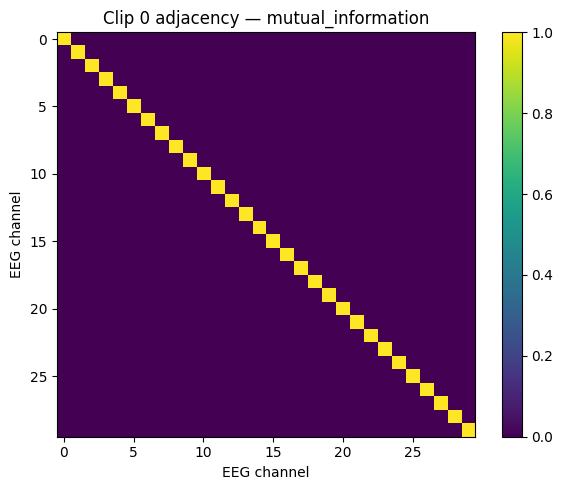

In [16]:
# Cell 29 — Visualize one cached adjacency matrix

plt.figure(figsize=(6, 5))
plt.imshow(np.asarray(clip_adjacency[0]), aspect='auto')
plt.title(f'Clip 0 adjacency — {CFG.adjacency_method}')
plt.xlabel('EEG channel')
plt.ylabel('EEG channel')
plt.colorbar()
plt.tight_layout()
plt.show()


# Cell 30 — Section 5 end — Graph cache ready

**Section 5 complete.** Clip-level graph matrices are cached and reusable.


# Cell 31 — Section 6 start — Nested-CV splits

# Section 6 — Build exact outer and inner splits for cross-9

- **Cross-9:** outer and inner folds are subject-disjoint.
- **Intra-9:** folds are assigned by second positions inside every video, ensuring every subject and video contributes to each outer fold without overlapping one-second samples.


In [17]:
# Cell 32 — Define cross-subject and intra-subject nested-CV splits

def build_cross_subject_splits(seed: int = 42) -> List[Dict]:
    rng = np.random.default_rng(seed)
    shuffled_subjects = rng.permutation(NUM_SUBJECTS)
    if NUM_SUBJECTS == 123:
        test_subject_folds = [shuffled_subjects[index * 12:(index + 1) * 12] for index in range(9)]
        test_subject_folds.append(shuffled_subjects[108:])
    else:
        test_subject_folds = [np.asarray(group, dtype=np.int64) for group in np.array_split(shuffled_subjects, CFG.outer_folds)]

    splits = []
    for outer_fold, test_subjects in enumerate(test_subject_folds):
        train_subjects = np.setdiff1d(shuffled_subjects, test_subjects, assume_unique=True)
        inner_val_groups = np.array_split(train_subjects, CFG.inner_folds)
        inner = []
        for inner_fold, val_subjects in enumerate(inner_val_groups):
            inner_train_subjects = np.setdiff1d(train_subjects, val_subjects, assume_unique=True)
            inner.append({
                'fold': inner_fold,
                'train_idx': np.flatnonzero(np.isin(subject_ids, inner_train_subjects)),
                'val_idx': np.flatnonzero(np.isin(subject_ids, val_subjects)),
                'train_subjects': inner_train_subjects,
                'val_subjects': val_subjects,
            })
        splits.append({
            'outer_fold': outer_fold,
            'train_idx': np.flatnonzero(np.isin(subject_ids, train_subjects)),
            'test_idx': np.flatnonzero(np.isin(subject_ids, test_subjects)),
            'train_subjects': train_subjects,
            'test_subjects': test_subjects,
            'inner': inner,
        })
    return splits

def build_intra_subject_splits() -> List[Dict]:
    # Paper-aligned: the 30 one-second windows of every video and subject
    # are distributed equally across ten folds by second position.
    outer_assignment = second_ids % CFG.outer_folds
    splits = []
    for outer_fold in range(CFG.outer_folds):
        test_mask = outer_assignment == outer_fold
        train_mask = ~test_mask
        remaining_seconds = np.array([
            second for second in range(SECONDS_PER_VIDEO)
            if second % CFG.outer_folds != outer_fold
        ])
        inner_groups = np.array_split(remaining_seconds, CFG.inner_folds)
        inner = []
        for inner_fold, val_seconds in enumerate(inner_groups):
            val_mask = train_mask & np.isin(second_ids, val_seconds)
            inner_train_mask = train_mask & ~val_mask
            inner.append({
                'fold': inner_fold,
                'train_idx': np.flatnonzero(inner_train_mask),
                'val_idx': np.flatnonzero(val_mask),
                'val_seconds': val_seconds,
            })
        splits.append({
            'outer_fold': outer_fold,
            'train_idx': np.flatnonzero(train_mask),
            'test_idx': np.flatnonzero(test_mask),
            'test_seconds': np.flatnonzero(np.arange(SECONDS_PER_VIDEO) % CFG.outer_folds == outer_fold),
            'inner': inner,
        })
    return splits


In [18]:
# Cell 33 — Load or create a dataset-specific split cache

SPLIT_PATH = SPLIT_DIR / (
    f'{CFG.protocol}_outer{CFG.outer_folds}_inner{CFG.inner_folds}_'
    f'n{NUM_SUBJECTS}_{DATASET_FINGERPRINT[:12]}_seed{CFG.seed}.pkl'
)
if SPLIT_PATH.exists():
    with open(SPLIT_PATH, 'rb') as handle:
        CV_SPLITS = pickle.load(handle)
    print('Loaded cached splits:', SPLIT_PATH)
else:
    CV_SPLITS = (
        build_cross_subject_splits(CFG.seed)
        if CFG.protocol == 'cross_subject'
        else build_intra_subject_splits()
    )
    temporary = SPLIT_PATH.with_suffix('.pkl.tmp')
    with open(temporary, 'wb') as handle:
        pickle.dump(CV_SPLITS, handle, protocol=pickle.HIGHEST_PROTOCOL)
    temporary.replace(SPLIT_PATH)
    print('Saved split cache:', SPLIT_PATH)

assert len(CV_SPLITS) == CFG.outer_folds


Loaded cached splits: /kaggle/working/hetemotionnet_processed_FACED_cross_9_full_resumable/splits/cross_subject_outer10_inner3_n123_7fa7c3193e19_seed42.pkl


In [19]:
# Cell 34 — Verify split leakage, sizes, and class coverage

split_rows = []
for outer in CV_SPLITS:
    train_idx = outer['train_idx']
    test_idx = outer['test_idx']
    assert np.intersect1d(train_idx, test_idx).size == 0
    assert np.union1d(train_idx, test_idx).size == len(sample_labels)
    if CFG.protocol == 'cross_subject':
        assert np.intersect1d(subject_ids[train_idx], subject_ids[test_idx]).size == 0
    for inner in outer['inner']:
        assert np.intersect1d(inner['train_idx'], inner['val_idx']).size == 0
        assert np.intersect1d(inner['val_idx'], test_idx).size == 0
        assert set(np.unique(sample_labels[inner['val_idx']])) == set(range(NUM_CLASSES))
    split_rows.append({
        'outer_fold': outer['outer_fold'] + 1,
        'train_samples': len(train_idx),
        'test_samples': len(test_idx),
        'train_subjects': len(np.unique(subject_ids[train_idx])),
        'train_subject_file_numbers': len(np.unique(original_subject_numbers[train_idx])),
        'test_subjects': len(np.unique(subject_ids[test_idx])),
        'test_classes': len(np.unique(sample_labels[test_idx])),
    })
split_table = pd.DataFrame(split_rows)
display(split_table)


,outer_fold,train_samples,test_samples,train_subjects,train_subject_file_numbers,test_subjects,test_classes
0,1,93240,10080,111,111,12,9
1,2,93240,10080,111,111,12,9
2,3,93240,10080,111,111,12,9
3,4,93240,10080,111,111,12,9
4,5,93240,10080,111,111,12,9
5,6,93240,10080,111,111,12,9
6,7,93240,10080,111,111,12,9
7,8,93240,10080,111,111,12,9
8,9,93240,10080,111,111,12,9
9,10,90720,12600,108,108,15,9


# Cell 35 — Section 6 end — Splits verified

**Section 6 complete.** All outer and inner folds are cached and leakage checks passed.


# Cell 36 — Section 7 start — Dataset and data loaders

# Section 7 — PyTorch dataset and loaders

The temporal tensor and adjacency are indexed by clip ID, preventing 30-fold duplication in memory.


In [20]:
# Cell 37 — Define the two-stream dataset and a stable DataLoader

class FACEDHetDataset(Dataset):
    def __init__(self, indices: np.ndarray):
        self.indices = np.asarray(indices, dtype=np.int64)

    def __len__(self) -> int:
        return int(self.indices.size)

    def __getitem__(self, item: int):
        sample_index = int(self.indices[item])
        clip_index = int(clip_ids[sample_index])
        x_f = torch.from_numpy(np.asarray(x_frequency[sample_index], dtype=np.float32).copy())
        x_t = torch.from_numpy(np.asarray(x_temporal_by_clip[clip_index], dtype=np.float32).copy())
        adjacency = torch.from_numpy(np.asarray(clip_adjacency[clip_index], dtype=np.float32).copy())
        label = torch.tensor(int(sample_labels[sample_index]), dtype=torch.long)
        return x_f, x_t, adjacency, label, sample_index


def resolve_num_workers(requested: int) -> int:
    """Choose a conservative worker count for Kaggle and local reruns."""
    available_cpus = max(1, os.cpu_count() or 1)
    requested = max(0, int(requested))
    if os.name == 'nt':
        return 0
    return min(requested, max(0, available_cpus - 1), 4)


EFFECTIVE_NUM_WORKERS = resolve_num_workers(CFG.num_workers)
PIN_MEMORY = DEVICE.type == 'cuda'


def make_loader(indices: np.ndarray, shuffle: bool, batch_size: Optional[int] = None) -> DataLoader:
    loader_kwargs = {
        'dataset': FACEDHetDataset(indices),
        'batch_size': batch_size or CFG.batch_size,
        'shuffle': shuffle,
        'num_workers': EFFECTIVE_NUM_WORKERS,
        'pin_memory': PIN_MEMORY,
        # Persistent workers can accumulate across hundreds of nested-CV
        # loaders. Disabling them is slower to initialize but more reliable.
        'persistent_workers': False,
        'drop_last': False,
    }
    if EFFECTIVE_NUM_WORKERS > 0:
        loader_kwargs['prefetch_factor'] = 2
    return DataLoader(**loader_kwargs)


print('Effective DataLoader workers:', EFFECTIVE_NUM_WORKERS)
print('Pinned host memory:', PIN_MEMORY)


Effective DataLoader workers: 2
Pinned host memory: True


In [21]:
# Cell 38 — Inspect one mini-batch

preview_loader = make_loader(CV_SPLITS[0]['inner'][0]['val_idx'][:1024], shuffle=False, batch_size=16)
batch_x_f, batch_x_t, batch_adj, batch_y, batch_indices = next(iter(preview_loader))
print('x_F batch:', tuple(batch_x_f.shape))
print('x_T batch:', tuple(batch_x_t.shape))
print('adjacency batch:', tuple(batch_adj.shape))
print('labels batch:', tuple(batch_y.shape))
print('sample-index batch:', tuple(batch_indices.shape))


x_F batch: (16, 30, 5)
x_T batch: (16, 30, 30)
adjacency batch: (16, 30, 30)
labels batch: (16,)
sample-index batch: (16,)


# Cell 39 — Section 7 end — Data loaders ready

**Section 7 complete.**


# Cell 40 — Section 8 start — HetEmotionNet model

# Section 8 — Standalone HetEmotionNet-style architecture

Each stream applies normalized graph propagation followed by a bidirectional GRU. The two stream embeddings are projected, flattened, fused, and classified into nine emotions.


In [22]:
# Cell 41 — Define GNN4EEG-style graph normalization and graph–BiGRU stream

def normalize_adjacency(adjacency: torch.Tensor) -> torch.Tensor:
    batch, nodes, _ = adjacency.shape
    identity = torch.eye(nodes, device=adjacency.device, dtype=adjacency.dtype).expand(batch, -1, -1)
    off_diagonal = adjacency * (1.0 - identity)
    adjacency_with_loops = off_diagonal + identity
    degree = adjacency_with_loops.sum(dim=-1).clamp_min(1e-6)
    inv_sqrt = degree.pow(-0.5)
    return inv_sqrt.unsqueeze(-1) * adjacency_with_loops * inv_sqrt.unsqueeze(-2)

class GraphBiGRUStream(nn.Module):
    """Standalone equivalent of GNN4EEG STDCN_with_GRU."""

    def __init__(self, num_nodes: int, sequence_length: int):
        super().__init__()
        self.num_nodes = num_nodes
        self.sequence_length = sequence_length
        self.graph_scale = nn.Parameter(torch.tensor(10.0))
        self.gru = nn.GRU(
            input_size=num_nodes,
            hidden_size=num_nodes,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )
        self.batch_norm = nn.BatchNorm1d(sequence_length)

    def forward(self, x: torch.Tensor, adjacency: torch.Tensor) -> torch.Tensor:
        normalized = normalize_adjacency(adjacency)
        graph_features = F.leaky_relu(torch.bmm(normalized, x) * self.graph_scale)
        sequence = graph_features.transpose(1, 2)  # (batch, sequence_length, nodes)
        recurrent, _ = self.gru(sequence)
        recurrent = self.batch_norm(recurrent)
        return recurrent.transpose(1, 2)  # (batch, 2*nodes, sequence_length)


In [23]:
# Cell 42 — Define the complete nine-class GNN4EEG HetEmotionNet classifier

class HetEmotionNet(nn.Module):
    def __init__(self, hidden_dim: int, dropout: float, num_classes: int = 9):
        super().__init__()
        self.input_dropout = nn.Dropout(dropout)
        self.frequency_stream = GraphBiGRUStream(NUM_NODES, NUM_BANDS)
        self.temporal_stream = GraphBiGRUStream(NUM_NODES, SECONDS_PER_VIDEO)

        projection_dim = SECONDS_PER_VIDEO // 2
        self.frequency_projection = nn.Linear(NUM_BANDS, projection_dim)
        self.temporal_projection = nn.Linear(SECONDS_PER_VIDEO, projection_dim)

        fused_dim = 2 * NUM_NODES * projection_dim * 2
        self.fusion = nn.Linear(fused_dim, hidden_dim)
        self.activation = nn.LeakyReLU()
        self.output = nn.Linear(hidden_dim, num_classes)

    def forward(self, x_f: torch.Tensor, x_t: torch.Tensor, adjacency: torch.Tensor) -> torch.Tensor:
        x_f = self.input_dropout(x_f)
        x_t = self.input_dropout(x_t)
        frequency = self.frequency_stream(x_f, adjacency)
        temporal = self.temporal_stream(x_t, adjacency)
        frequency = self.frequency_projection(frequency).flatten(1)
        temporal = self.temporal_projection(temporal).flatten(1)
        fused = torch.cat([frequency, temporal], dim=1)
        return self.output(self.activation(self.fusion(fused)))


In [24]:
# Cell 43 — Run a model shape and gradient smoke test

smoke_model = HetEmotionNet(hidden_dim=20, dropout=CFG.dropout, num_classes=NUM_CLASSES).to(DEVICE)
smoke_x_f = batch_x_f[:4].to(DEVICE, non_blocking=PIN_MEMORY)
smoke_x_t = batch_x_t[:4].to(DEVICE, non_blocking=PIN_MEMORY)
smoke_adj = batch_adj[:4].to(DEVICE, non_blocking=PIN_MEMORY)
smoke_y = batch_y[:4].to(DEVICE, non_blocking=PIN_MEMORY)
smoke_logits = smoke_model(smoke_x_f, smoke_x_t, smoke_adj)
smoke_loss = F.cross_entropy(smoke_logits, smoke_y)
smoke_loss.backward()
print('Logit shape:', tuple(smoke_logits.shape))
print('Finite loss:', float(smoke_loss.detach().cpu()))
assert smoke_logits.shape == (4, NUM_CLASSES)
del smoke_model, smoke_logits, smoke_loss, smoke_x_f, smoke_x_t, smoke_adj, smoke_y
clear_runtime_cache()


Logit shape: (4, 9)
Finite loss: 2.242586135864258


# Cell 44 — Section 8 end — Model verified

**Section 8 complete.** A forward and backward pass succeeded.


# Cell 45 — Section 9 start — Training and checkpoint utilities

# Section 9 — Training, evaluation, and epoch-level resume

Exact NCV selects hyperparameters and epoch count from the average inner-validation accuracy. No test fold is used during selection.


In [25]:
# Cell 46 — Define metric and regularization helpers

def regularization_loss(model: nn.Module, l1_weight: float, l2_weight: float) -> torch.Tensor:
    # Mean-normalized penalties keep coefficients comparable across hidden dimensions.
    l1_terms = [parameter.abs().mean() for parameter in model.parameters() if parameter.requires_grad]
    l2_terms = [parameter.pow(2).mean() for parameter in model.parameters() if parameter.requires_grad]
    l1 = torch.stack(l1_terms).mean() if l1_terms else torch.tensor(0.0, device=DEVICE)
    l2 = torch.stack(l2_terms).mean() if l2_terms else torch.tensor(0.0, device=DEVICE)
    return l1_weight * l1 + l2_weight * l2

def calculate_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0
    )
    return {
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'macro_precision': float(precision),
        'macro_recall': float(recall),
        'macro_f1': float(f1),
    }


In [26]:
# Cell 47 — Define portable mixed-precision contexts, one training epoch, and evaluation


def mixed_precision_enabled() -> bool:
    return bool(CFG.mixed_precision and DEVICE.type == 'cuda' and CUDA_USABLE)


def autocast_context():
    """Return a compatible autocast context across recent PyTorch versions."""
    if not mixed_precision_enabled():
        return contextlib.nullcontext()
    try:
        return torch.amp.autocast(device_type='cuda', dtype=torch.float16, enabled=True)
    except (AttributeError, TypeError):
        return torch.cuda.amp.autocast(dtype=torch.float16, enabled=True)


def train_one_epoch(model, loader, optimizer, scaler) -> Dict[str, float]:
    model.train()
    running_loss = 0.0
    y_true, y_pred = [], []

    for x_f, x_t, adjacency, labels, _ in loader:
        x_f = x_f.to(DEVICE, non_blocking=PIN_MEMORY)
        x_t = x_t.to(DEVICE, non_blocking=PIN_MEMORY)
        adjacency = adjacency.to(DEVICE, non_blocking=PIN_MEMORY)
        labels = labels.to(DEVICE, non_blocking=PIN_MEMORY)
        optimizer.zero_grad(set_to_none=True)

        with autocast_context():
            logits = model(x_f, x_t, adjacency)
            loss = F.cross_entropy(logits, labels)
            loss = loss + regularization_loss(model, CFG.l1_reg, CFG.l2_reg)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), CFG.gradient_clip)
        scaler.step(optimizer)
        scaler.update()

        running_loss += float(loss.detach().cpu()) * labels.size(0)
        y_true.append(labels.detach().cpu().numpy())
        y_pred.append(logits.argmax(dim=1).detach().cpu().numpy())

    true = np.concatenate(y_true)
    pred = np.concatenate(y_pred)
    metrics = calculate_metrics(true, pred)
    metrics['loss'] = running_loss / len(loader.dataset)
    return metrics


@torch.no_grad()
def evaluate_model(model, loader, return_predictions: bool = False):
    model.eval()
    running_loss = 0.0
    y_true, y_pred, probabilities, sample_indices = [], [], [], []

    for x_f, x_t, adjacency, labels, indices in loader:
        x_f = x_f.to(DEVICE, non_blocking=PIN_MEMORY)
        x_t = x_t.to(DEVICE, non_blocking=PIN_MEMORY)
        adjacency = adjacency.to(DEVICE, non_blocking=PIN_MEMORY)
        labels = labels.to(DEVICE, non_blocking=PIN_MEMORY)
        with autocast_context():
            logits = model(x_f, x_t, adjacency)
            loss = F.cross_entropy(logits, labels)

        running_loss += float(loss.detach().cpu()) * labels.size(0)
        probs = torch.softmax(logits, dim=1)
        y_true.append(labels.detach().cpu().numpy())
        y_pred.append(logits.argmax(dim=1).detach().cpu().numpy())
        probabilities.append(probs.detach().cpu().numpy())
        sample_indices.append(indices.numpy())

    true = np.concatenate(y_true)
    pred = np.concatenate(y_pred)
    metrics = calculate_metrics(true, pred)
    metrics['loss'] = running_loss / len(loader.dataset)
    if return_predictions:
        return metrics, true, pred, np.concatenate(probabilities), np.concatenate(sample_indices)
    return metrics


### Automatic emergency checkpoint export\n
\n
From this point onward, a Python error or manual interruption creates `hetemotionnet_processed_FACED_cross_9_full_resumable_emergency_checkpoints.zip` in `/kaggle/working`. The archive contains all `last.pt` files saved so far, their histories/completion markers, split definitions, results, and a failure report. A hard kernel or virtual-machine termination cannot run cleanup code; however, each completed epoch is still written atomically to `last.pt`.\n

In [27]:
# Cell 48 — Define CUDA/CPU-portable checkpoint save and automatic resume helpers

CHECKPOINT_FORMAT_VERSION = 2

# Cross-file-style resume bundle. Unlike a final-only ZIP, this archive is
# created before training, refreshed periodically, refreshed after each
# completed run, and refreshed once more when an exception/interrupt occurs.
EXPORT_ROOT = KAGGLE_WORKING if KAGGLE_WORKING.exists() else WORK_ROOT.parent
RESUME_BUNDLE_PATH = EXPORT_ROOT / f'{TASK_SLUG}_resume_bundle.zip'
LAST_EXCEPTION_PATH = PROFILE_ROOT / 'last_training_exception.json'
_BUNDLE_IN_PROGRESS = False


def atomic_json_dump(payload: Dict[str, Any], path: Path) -> None:
    """Write JSON atomically so a stop cannot leave a half-written marker."""
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary = path.with_suffix(path.suffix + '.tmp')
    if temporary.exists():
        temporary.unlink()
    with open(temporary, 'w', encoding='utf-8') as handle:
        json.dump(payload, handle, indent=2, default=str)
        handle.flush()
        os.fsync(handle.fileno())
    os.replace(temporary, path)


def _valid_json(path: Path) -> bool:
    try:
        with open(path, 'r', encoding='utf-8') as handle:
            json.load(handle)
        return True
    except Exception:
        return False


def _history_row_count(path: Path) -> int:
    try:
        return int(len(pd.read_csv(path)))
    except Exception:
        return -1


def _is_inner_run_dir(run_dir: Path) -> bool:
    return any(part.startswith('inner_') for part in run_dir.parts)


def prune_completed_inner_checkpoints() -> int:
    """
    Remove only completed inner-run model/optimizer checkpoints.

    Their history.csv + complete.json are sufficient for hyperparameter
    selection. Active inner checkpoints and every final-model checkpoint stay
    in the bundle, matching the compact structure used by cross9-resume.ipynb.
    """
    removed = 0
    if not CHECKPOINT_DIR.exists():
        return removed

    for latest_path in CHECKPOINT_DIR.rglob('last.pt'):
        run_dir = latest_path.parent
        if not _is_inner_run_dir(run_dir):
            continue

        complete_path = run_dir / 'complete.json'
        history_path = run_dir / 'history.csv'
        if not (complete_path.exists() and history_path.exists()):
            continue
        if not _valid_json(complete_path):
            continue

        try:
            with open(complete_path, 'r', encoding='utf-8') as handle:
                complete = json.load(handle)
            target_epochs = int(complete.get('epochs', -1))
            completed = bool(complete.get('completed', False))
        except Exception:
            continue

        if completed and target_epochs > 0 and _history_row_count(history_path) >= target_epochs:
            for checkpoint_file in (
                latest_path,
                latest_path.with_suffix(latest_path.suffix + '.tmp'),
            ):
                if checkpoint_file.exists():
                    checkpoint_file.unlink()
                    removed += 1
    return removed


def _resume_bundle_files() -> List[Path]:
    """Collect the small, sufficient state needed to continue on another run."""
    files: set = set()

    # Preserve every profile, not only the currently selected profile.
    for directory_name in ('checkpoints', 'results'):
        for directory in WORK_ROOT.rglob(directory_name):
            if directory.is_dir():
                files.update(
                    path for path in directory.rglob('*')
                    if path.is_file() and not path.name.endswith('.tmp')
                )

    if SPLIT_DIR.exists():
        files.update(
            path for path in SPLIT_DIR.rglob('*')
            if path.is_file() and not path.name.endswith('.tmp')
        )

    for fixed_path in (
        WORK_ROOT / 'run_manifest.json',
        WORK_ROOT / 'checkpoint_inventory.csv',
        PROFILE_ROOT / 'last_training_exception.json',
    ):
        if fixed_path.is_file():
            files.add(fixed_path)

    return sorted(files)


def create_resume_bundle(display_link: bool = False) -> Path:
    """
    Atomically create/refresh one downloadable resume ZIP.

    The ZIP contains the top-level TASK_SLUG workspace folder, so the existing
    automatic restore cell can discover and merge it without manual paths.
    """
    global _BUNDLE_IN_PROGRESS

    # Avoid recursion if an IPython failure hook fires while bundle creation is
    # already reporting an unrelated problem.
    if _BUNDLE_IN_PROGRESS:
        if RESUME_BUNDLE_PATH.exists():
            return RESUME_BUNDLE_PATH
        raise RuntimeError('Resume bundle creation is already in progress.')

    _BUNDLE_IN_PROGRESS = True
    temporary = RESUME_BUNDLE_PATH.with_suffix('.zip.tmp')
    try:
        EXPORT_ROOT.mkdir(parents=True, exist_ok=True)
        prune_completed_inner_checkpoints()
        source_files = _resume_bundle_files()

        manifest = {
            'workspace_name': WORK_ROOT.name,
            'created_unix_time': time.time(),
            'run_profile': CFG.run_profile,
            'completed_markers': len(list(WORK_ROOT.rglob('complete.json'))),
            'active_last_checkpoints': len(list(WORK_ROOT.rglob('last.pt'))),
            'source_file_count': len(source_files),
            'config': asdict(CFG),
        }

        if temporary.exists():
            temporary.unlink()

        with zipfile.ZipFile(
            temporary,
            'w',
            compression=zipfile.ZIP_DEFLATED,
            compresslevel=1,
            allowZip64=True,
        ) as archive:
            for file_path in source_files:
                if file_path.is_file():
                    archive.write(
                        file_path,
                        arcname=file_path.relative_to(WORK_ROOT.parent),
                    )

            archive.writestr(
                f'{WORK_ROOT.name}/resume_manifest.json',
                json.dumps(manifest, indent=2, default=str),
            )

        os.replace(temporary, RESUME_BUNDLE_PATH)

        print(
            f'Resume bundle refreshed: {RESUME_BUNDLE_PATH} | '
            f'{manifest["active_last_checkpoints"]} active checkpoint(s), '
            f'{manifest["completed_markers"]} completed run(s)'
        )
        if display_link:
            try:
                from IPython.display import FileLink
                display(FileLink(str(RESUME_BUNDLE_PATH)))
            except Exception:
                print('Download it from the Kaggle Files/Output panel.')
        return RESUME_BUNDLE_PATH
    finally:
        _BUNDLE_IN_PROGRESS = False
        if temporary.exists():
            temporary.unlink()


def export_emergency_checkpoint_zip(
    error: Optional[BaseException] = None,
    context: str = 'Notebook interruption or error',
    force: bool = False,
) -> Optional[Path]:
    """Record the failure, then refresh the same normal resume bundle."""
    del force  # Kept for compatibility with earlier calls in this notebook.
    try:
        error_record = {
            'context': context,
            'error_type': type(error).__name__ if error is not None else None,
            'error_message': str(error) if error is not None else None,
            'error_repr': repr(error) if error is not None else None,
            'unix_time': time.time(),
        }
        atomic_json_dump(error_record, LAST_EXCEPTION_PATH)
        bundle_path = create_resume_bundle(display_link=True)
        print(f'Emergency resume bundle created: {bundle_path}')
        return bundle_path
    except BaseException as bundle_error:
        print(f'Could not create emergency resume bundle: {bundle_error!r}')
        return None


def _auto_export_after_failed_cell(result: Any) -> None:
    """Refresh the resume ZIP whenever a later IPython cell fails."""
    error = getattr(result, 'error_in_exec', None) or getattr(result, 'error_before_exec', None)
    if error is not None:
        export_emergency_checkpoint_zip(
            error=error,
            context='Automatic export after a failed/interrupted notebook cell',
        )


try:
    _ipython = get_ipython()
    _old_handler = globals().get('_HETEMOTIONNET_FAILURE_HANDLER')
    if _old_handler is not None:
        with contextlib.suppress(Exception):
            _ipython.events.unregister('post_run_cell', _old_handler)
    _HETEMOTIONNET_FAILURE_HANDLER = _auto_export_after_failed_cell
    _ipython.events.register('post_run_cell', _HETEMOTIONNET_FAILURE_HANDLER)
    print('Automatic failure export hook registered.')
except Exception as hook_error:
    print(
        'IPython hook was unavailable; training-loop and outer-loop protection '
        f'remain active. {type(hook_error).__name__}: {hook_error}'
    )


def atomic_torch_save(payload: Dict, path: Path) -> None:
    """Write a checkpoint atomically so runtime interruption cannot corrupt last.pt."""
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary = path.with_suffix(path.suffix + '.tmp')
    if temporary.exists():
        temporary.unlink()
    with open(temporary, 'wb') as handle:
        torch.save(payload, handle)
        handle.flush()
        os.fsync(handle.fileno())
    os.replace(temporary, path)


def safe_torch_load(path: Path, map_location: Any = 'cpu') -> Dict[str, Any]:
    """Load full training checkpoints across old and new PyTorch APIs."""
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)


def create_grad_scaler(enabled: bool):
    """Create a GradScaler using whichever API the installed PyTorch supports."""
    try:
        return torch.amp.GradScaler(device='cuda', enabled=enabled)
    except (AttributeError, TypeError):
        try:
            return torch.amp.GradScaler('cuda', enabled=enabled)
        except (AttributeError, TypeError):
            return torch.cuda.amp.GradScaler(enabled=enabled)


def optimizer_state_to_device(optimizer: torch.optim.Optimizer, device: torch.device) -> None:
    """Move Adam moments after a CPU-mapped checkpoint is restored."""
    for state in optimizer.state.values():
        for key, value in list(state.items()):
            if torch.is_tensor(value):
                state[key] = value.to(device)


def extract_model_state(checkpoint: Dict[str, Any]) -> Dict[str, torch.Tensor]:
    state = checkpoint.get('model_state')
    if state is None:
        state = checkpoint.get('state_dict')
    if state is None:
        raise KeyError('Checkpoint has no model_state or state_dict.')
    # Support checkpoints saved from nn.DataParallel.
    if state and all(str(key).startswith('module.') for key in state):
        state = {str(key)[7:]: value for key, value in state.items()}
    return state


def load_model_state_compatible(model: nn.Module, checkpoint: Dict[str, Any]) -> None:
    model.load_state_dict(extract_model_state(checkpoint), strict=True)


def capture_rng_state() -> Dict[str, Any]:
    state: Dict[str, Any] = {
        'python': random.getstate(),
        'numpy': np.random.get_state(),
        'torch_cpu': torch.get_rng_state(),
    }
    if DEVICE.type == 'cuda':
        with contextlib.suppress(Exception):
            state['torch_cuda'] = torch.cuda.get_rng_state(DEVICE)
    return state


def restore_rng_state(state: Optional[Dict[str, Any]]) -> None:
    if not state:
        return
    with contextlib.suppress(Exception):
        random.setstate(state['python'])
    with contextlib.suppress(Exception):
        np.random.set_state(state['numpy'])
    with contextlib.suppress(Exception):
        torch.set_rng_state(state['torch_cpu'].cpu())
    if DEVICE.type == 'cuda' and state.get('torch_cuda') is not None:
        with contextlib.suppress(Exception):
            torch.cuda.set_rng_state(state['torch_cuda'].cpu(), DEVICE)


def fit_with_resume(
    run_dir: Path,
    train_indices: np.ndarray,
    val_indices: Optional[np.ndarray],
    hidden_dim: int,
    learning_rate: float,
    epochs: int,
) -> Tuple[pd.DataFrame, Path]:
    run_dir.mkdir(parents=True, exist_ok=True)
    last_path = run_dir / 'last.pt'
    history_path = run_dir / 'history.csv'
    complete_path = run_dir / 'complete.json'
    is_inner_run = _is_inner_run_dir(run_dir)

    # Completed inner runs intentionally have their large last.pt removed from
    # the rolling ZIP. Their complete marker and full history are enough to
    # skip retraining and continue hyperparameter selection.
    if complete_path.exists() and history_path.exists():
        try:
            with open(complete_path, 'r', encoding='utf-8') as handle:
                complete_record = json.load(handle)
            completed_history = pd.read_csv(history_path).sort_values('epoch')
            completed_ok = bool(complete_record.get('completed', False))
            enough_rows = len(completed_history) >= int(complete_record.get('epochs', epochs))
            checkpoint_available = last_path.exists() or is_inner_run
            if completed_ok and enough_rows and checkpoint_available:
                print(f'Loaded completed run without retraining: {run_dir}')
                return completed_history, last_path
        except Exception as exc:
            print(f'Completion marker could not be reused; checking checkpoint instead: {exc}')

    # Remove only stale temporary files. A valid last.pt is never touched.
    stale_temp = last_path.with_suffix(last_path.suffix + '.tmp')
    if stale_temp.exists():
        stale_temp.unlink()

    model = HetEmotionNet(hidden_dim, CFG.dropout, CFG.num_classes).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    scaler = create_grad_scaler(mixed_precision_enabled())
    start_epoch = 1
    history: List[Dict[str, Any]] = []

    if history_path.exists():
        try:
            history = pd.read_csv(history_path).to_dict('records')
        except Exception as exc:
            print(f'Warning: history could not be read and will be rebuilt: {exc}')
            history = []

    if last_path.exists():
        try:
            # Always map to CPU first. This is what makes a CUDA checkpoint
            # portable to another GPU or a CPU-only runtime.
            checkpoint = safe_torch_load(last_path, map_location='cpu')

            saved_hidden = checkpoint.get('hidden_dim')
            if saved_hidden is not None and int(saved_hidden) != int(hidden_dim):
                raise ValueError(
                    f'hidden_dim mismatch: checkpoint={saved_hidden}, requested={hidden_dim}'
                )

            load_model_state_compatible(model, checkpoint)
            saved_epoch = int(checkpoint.get('epoch', 0))
            start_epoch = saved_epoch + 1

            optimizer_state = checkpoint.get('optimizer_state')
            if optimizer_state:
                try:
                    optimizer.load_state_dict(optimizer_state)
                    optimizer_state_to_device(optimizer, DEVICE)
                    # The directory name/config remains the source of truth.
                    for group in optimizer.param_groups:
                        group['lr'] = learning_rate
                except Exception as exc:
                    print(
                        'Optimizer state was incompatible with this PyTorch build; '
                        f'resuming weights with a fresh Adam optimizer. {type(exc).__name__}: {exc}'
                    )
                    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

            scaler_state = checkpoint.get('scaler_state')
            if mixed_precision_enabled() and scaler_state:
                try:
                    scaler.load_state_dict(scaler_state)
                except Exception as exc:
                    print(
                        'AMP scaler state was incompatible and was reset safely: '
                        f'{type(exc).__name__}: {exc}'
                    )
                    scaler = create_grad_scaler(True)

            restore_rng_state(checkpoint.get('rng_state'))
            print(
                f'Resuming {run_dir.name} from epoch {start_epoch} '
                f'(saved on {checkpoint.get("saved_device", "unknown device")}, '
                f'loaded on {DEVICE}).'
            )
            del checkpoint
        except Exception as exc:
            # Preserve the unreadable/incompatible file for inspection and run
            # from epoch 1 instead of crashing the whole nested-CV notebook.
            print(
                f'Checkpoint could not be resumed: {last_path}\n'
                f'{type(exc).__name__}: {exc}\n'
                'The file was preserved. This run will restart from epoch 1.'
            )
            start_epoch = 1
            history = []
            model = HetEmotionNet(hidden_dim, CFG.dropout, CFG.num_classes).to(DEVICE)
            optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
            scaler = create_grad_scaler(mixed_precision_enabled())

    # The runtime can stop after last.pt is saved but before complete.json is
    # written. In that case, mark the already-finished run complete now.
    if last_path.exists() and start_epoch > epochs:
        if not complete_path.exists():
            with open(complete_path, 'w') as handle:
                json.dump({
                    'epochs': epochs,
                    'last_epoch': start_epoch - 1,
                    'completed': True,
                    'recovered_from_checkpoint': True,
                }, handle, indent=2)
        return pd.DataFrame(history).sort_values('epoch') if history else pd.DataFrame(), last_path

    train_loader = make_loader(train_indices, shuffle=True)
    val_loader = make_loader(val_indices, shuffle=False) if val_indices is not None else None

    try:
        for epoch in range(start_epoch, epochs + 1):
            train_metrics = train_one_epoch(model, train_loader, optimizer, scaler)
            val_metrics = evaluate_model(model, val_loader) if val_loader is not None else {}
            row = {'epoch': epoch, **{f'train_{key}': value for key, value in train_metrics.items()}}
            row.update({f'val_{key}': value for key, value in val_metrics.items()})
            history = [item for item in history if int(item['epoch']) != epoch] + [row]
            history_df = pd.DataFrame(history).sort_values('epoch')
            history_df.to_csv(history_path, index=False)

            checkpoint_payload = {
                'checkpoint_format_version': CHECKPOINT_FORMAT_VERSION,
                'epoch': epoch,
                'model_state': model.state_dict(),
                'optimizer_state': optimizer.state_dict(),
                'scaler_state': scaler.state_dict() if mixed_precision_enabled() else {},
                'rng_state': capture_rng_state(),
                'hidden_dim': hidden_dim,
                'learning_rate': learning_rate,
                'config': asdict(CFG),
                'python_version': sys.version.split()[0],
                'torch_version': torch.__version__,
                'torch_cuda_build': torch.version.cuda,
                'saved_device': str(DEVICE),
                'amp_enabled': mixed_precision_enabled(),
            }
            if CFG.save_every_epoch:
                atomic_torch_save(checkpoint_payload, last_path)

            message = f"Epoch {epoch:03d}/{epochs} | train acc {train_metrics['accuracy']:.4f}"
            if val_loader is not None:
                message += f" | val acc {val_metrics['accuracy']:.4f} | val F1 {val_metrics['macro_f1']:.4f}"
            print(message)

            if (
                CFG.refresh_bundle_every_n_epochs
                and epoch % int(CFG.refresh_bundle_every_n_epochs) == 0
            ):
                create_resume_bundle()
    except KeyboardInterrupt as exc:
        print(f'Interrupted safely. Latest completed epoch remains in: {last_path}')
        export_emergency_checkpoint_zip(
            error=exc,
            context=f'Manual interruption while training {run_dir}',
        )
        raise
    except Exception as exc:
        print(f'Training stopped. Latest valid atomic checkpoint remains in: {last_path}')
        export_emergency_checkpoint_zip(
            error=exc,
            context=f'Training error while running {run_dir}',
        )
        raise

    atomic_json_dump({
        'epochs': epochs,
        'last_epoch': epochs,
        'completed': True,
        'checkpoint': str(last_path),
        'torch_version': torch.__version__,
        'device': str(DEVICE),
    }, complete_path)

    # Exactly like the reference cross notebook: completed inner checkpoints
    # are removed after their history is safely recorded, then the rolling
    # resume bundle is refreshed. Final-model checkpoints are retained.
    if is_inner_run and last_path.exists():
        last_path.unlink()
    create_resume_bundle()

    history_frame = pd.DataFrame(history).sort_values('epoch')
    del model, optimizer, scaler, train_loader, val_loader
    clear_runtime_cache()
    return history_frame, last_path


Automatic failure export hook registered.


# Cell 49 — Section 9 end — Training utilities ready

**Section 9 complete.**


# Cell 50 — Section 10 start — Nested cross-validation runner

# Section 10 — Resumable NCV orchestration

For each outer fold:

1. train every `(hidden_dim, learning_rate)` pair on each of three inner folds;
2. average inner-validation accuracy at every epoch;
3. select the hyperparameters and epoch with highest mean inner accuracy;
4. initialize a fresh model on the complete outer-training set;
5. train for the selected epoch count;
6. evaluate once on the untouched outer test set.


In [28]:
# Cell 51 — Define inner-grid selection

def select_hyperparameters_for_outer_fold(outer: Dict) -> Dict:
    outer_number = outer['outer_fold'] + 1
    selection_path = RESULT_DIR / f'outer_{outer_number:02d}_selection.json'
    if selection_path.exists():
        with open(selection_path) as handle:
            selected = json.load(handle)
        print('Loaded completed selection:', selection_path)
        return selected

    candidate_rows = []
    for hidden_dim, learning_rate in product(CFG.effective_hidden_grid, CFG.effective_lr_grid):
        inner_histories = []
        for inner in outer['inner']:
            run_dir = (
                CHECKPOINT_DIR / f'outer_{outer_number:02d}' /
                f'h{hidden_dim}_lr{learning_rate:g}' / f"inner_{inner['fold'] + 1:02d}"
            )
            history, _ = fit_with_resume(
                run_dir=run_dir,
                train_indices=inner['train_idx'],
                val_indices=inner['val_idx'],
                hidden_dim=hidden_dim,
                learning_rate=learning_rate,
                epochs=CFG.effective_max_epochs,
            )
            inner_histories.append(history[['epoch', 'val_accuracy', 'val_macro_f1']].copy())

        merged = inner_histories[0].rename(columns={
            'val_accuracy': 'accuracy_0', 'val_macro_f1': 'f1_0'
        })
        for index, history in enumerate(inner_histories[1:], start=1):
            renamed = history.rename(columns={
                'val_accuracy': f'accuracy_{index}', 'val_macro_f1': f'f1_{index}'
            })
            merged = merged.merge(renamed, on='epoch', how='inner')

        accuracy_columns = [column for column in merged if column.startswith('accuracy_')]
        f1_columns = [column for column in merged if column.startswith('f1_')]
        merged['mean_val_accuracy'] = merged[accuracy_columns].mean(axis=1)
        merged['mean_val_macro_f1'] = merged[f1_columns].mean(axis=1)
        best_row = merged.sort_values(
            ['mean_val_accuracy', 'mean_val_macro_f1', 'epoch'], ascending=[False, False, True]
        ).iloc[0]
        candidate_rows.append({
            'hidden_dim': hidden_dim,
            'learning_rate': learning_rate,
            'selected_epoch': int(best_row['epoch']),
            'mean_val_accuracy': float(best_row['mean_val_accuracy']),
            'mean_val_macro_f1': float(best_row['mean_val_macro_f1']),
        })
        merged.to_csv(
            RESULT_DIR / f'outer_{outer_number:02d}_h{hidden_dim}_lr{learning_rate:g}_inner_curve.csv',
            index=False,
        )

    candidates = pd.DataFrame(candidate_rows).sort_values(
        ['mean_val_accuracy', 'mean_val_macro_f1'], ascending=False
    )
    candidates.to_csv(RESULT_DIR / f'outer_{outer_number:02d}_candidate_summary.csv', index=False)
    selected = candidates.iloc[0].to_dict()
    selected['hidden_dim'] = int(selected['hidden_dim'])
    selected['selected_epoch'] = int(selected['selected_epoch'])
    atomic_json_dump(selected, selection_path)
    display(candidates)
    create_resume_bundle()
    return selected


In [29]:
# Cell 52 — Define final outer-fold training and testing


def run_final_outer_fold(outer: Dict, selected: Dict) -> Dict:
    outer_number = outer['outer_fold'] + 1
    metrics_path = RESULT_DIR / f'outer_{outer_number:02d}_test_metrics.json'
    prediction_path = RESULT_DIR / f'outer_{outer_number:02d}_predictions.csv'
    final_dir = CHECKPOINT_DIR / f'outer_{outer_number:02d}' / 'final_model'

    if metrics_path.exists() and prediction_path.exists():
        with open(metrics_path) as handle:
            print('Loaded completed outer result:', metrics_path)
            return json.load(handle)

    history, checkpoint_path = fit_with_resume(
        run_dir=final_dir,
        train_indices=outer['train_idx'],
        val_indices=None,
        hidden_dim=int(selected['hidden_dim']),
        learning_rate=float(selected['learning_rate']),
        epochs=int(selected['selected_epoch']),
    )

    model = HetEmotionNet(int(selected['hidden_dim']), CFG.dropout, CFG.num_classes).to(DEVICE)
    checkpoint = safe_torch_load(checkpoint_path, map_location='cpu')
    load_model_state_compatible(model, checkpoint)
    del checkpoint
    model.eval()

    test_loader = make_loader(outer['test_idx'], shuffle=False)
    metrics, true, pred, probabilities, indices = evaluate_model(model, test_loader, return_predictions=True)

    metrics.update({
        'outer_fold': outer_number,
        'hidden_dim': int(selected['hidden_dim']),
        'learning_rate': float(selected['learning_rate']),
        'selected_epoch': int(selected['selected_epoch']),
        'test_samples': int(len(indices)),
        'evaluation_device': str(DEVICE),
        'torch_version': torch.__version__,
    })
    with open(metrics_path, 'w') as handle:
        json.dump(metrics, handle, indent=2)

    prediction_frame = pd.DataFrame({
        'sample_index': indices,
        'subject_position': subject_ids[indices],
        'subject_file_number': original_subject_numbers[indices],
        'video': video_ids[indices],
        'second': second_ids[indices],
        'clip_id': clip_ids[indices],
        'true_label': true,
        'predicted_label': pred,
        'true_emotion': [EMOTION_NAMES[index] for index in true],
        'predicted_emotion': [EMOTION_NAMES[index] for index in pred],
    })
    for class_id, emotion in enumerate(EMOTION_NAMES):
        prediction_frame[f'prob_{class_id}_{emotion.lower()}'] = probabilities[:, class_id]
    prediction_frame.to_csv(prediction_path, index=False)
    create_resume_bundle()

    del model, test_loader
    clear_runtime_cache()
    return metrics


In [30]:
# Cell 53 — Run all scheduled outer folds with automatic skipping/resume and failure ZIP export

fold_metrics = []

# Create the ZIP immediately, before the first long training call. It will be
# overwritten atomically with newer checkpoints throughout the run.
initial_resume_bundle = create_resume_bundle(display_link=True)
print('Rolling resume ZIP is active:', initial_resume_bundle)

try:
    for fold_index in CFG.effective_folds:
        outer = CV_SPLITS[int(fold_index)]
        print('\n' + '=' * 90)
        print(f"OUTER FOLD {int(fold_index) + 1}/{CFG.outer_folds}")
        print('=' * 90)
        selected = select_hyperparameters_for_outer_fold(outer)
        print('Selected configuration:', selected)
        metrics = run_final_outer_fold(outer, selected)
        fold_metrics.append(metrics)
        display(pd.DataFrame([metrics]))
        clear_runtime_cache()

    fold_metrics_df = pd.DataFrame(fold_metrics)
    if not fold_metrics_df.empty:
        fold_metrics_df = fold_metrics_df.sort_values('outer_fold')
        fold_metrics_df.to_csv(RESULT_DIR / 'fold_metrics_current_session.csv', index=False)
    display(fold_metrics_df)
except BaseException as exc:
    # Covers manual interruption plus failures outside fit_with_resume,
    # including selection, evaluation, and file I/O.
    error_record = {
        'error_type': type(exc).__name__,
        'error_message': str(exc),
        'error_repr': repr(exc),
        'unix_time': time.time(),
    }
    try:
        atomic_json_dump(error_record, LAST_EXCEPTION_PATH)
        emergency_bundle = create_resume_bundle(display_link=True)
        print(f'Emergency resume bundle created: {emergency_bundle}')
    except Exception as bundle_exc:
        print(f'Could not create emergency bundle: {bundle_exc!r}')
    raise


Resume bundle refreshed: /kaggle/working/hetemotionnet_processed_FACED_cross_9_full_resumable_resume_bundle.zip | 9 active checkpoint(s), 274 completed run(s)


/kaggle/working/hetemotionnet_processed_FACED_cross_9_full_resumable_resume_bundle.zip

Rolling resume ZIP is active: /kaggle/working/hetemotionnet_processed_FACED_cross_9_full_resumable_resume_bundle.zip

OUTER FOLD 1/10
Loaded completed selection: /kaggle/working/hetemotionnet_processed_FACED_cross_9_full_resumable/paper_ncv/results/outer_01_selection.json
Selected configuration: {'hidden_dim': 40, 'learning_rate': 0.01, 'selected_epoch': 3, 'mean_val_accuracy': 0.42397039897039895, 'mean_val_macro_f1': 0.4234627042276729}
Loaded completed outer result: /kaggle/working/hetemotionnet_processed_FACED_cross_9_full_resumable/paper_ncv/results/outer_01_test_metrics.json


,accuracy,macro_precision,macro_recall,macro_f1,loss,outer_fold,hidden_dim,learning_rate,selected_epoch,test_samples
0,0.486806,0.500485,0.489815,0.48551,1.816587,1,40,0.01,3,10080



OUTER FOLD 2/10
Loaded completed selection: /kaggle/working/hetemotionnet_processed_FACED_cross_9_full_resumable/paper_ncv/results/outer_02_selection.json
Selected configuration: {'hidden_dim': 20, 'learning_rate': 0.01, 'selected_epoch': 8, 'mean_val_accuracy': 0.43543543543543545, 'mean_val_macro_f1': 0.4310785616991934}
Loaded completed outer result: /kaggle/working/hetemotionnet_processed_FACED_cross_9_full_resumable/paper_ncv/results/outer_02_test_metrics.json


...


OUTER FOLD 10/10
Loaded completed run without retraining: /kaggle/working/hetemotionnet_processed_FACED_cross_9_full_resumable/paper_ncv/checkpoints/outer_10/h20_lr0.0001/inner_01
Loaded completed run without retraining: /kaggle/working/hetemotionnet_processed_FACED_cross_9_full_resumable/paper_ncv/checkpoints/outer_10/h20_lr0.0001/inner_02
Loaded completed run without retraining: /kaggle/working/hetemotionnet_processed_FACED_cross_9_full_resumable/paper_ncv/checkpoints/outer_10/h20_lr0.0001/inner_03
Loaded completed run without retraining: /kaggle/working/hetemotionnet_processed_FACED_cross_9_full_resumable/paper_ncv/checkpoints/outer_10/h20_lr0.001/inner_01
Loaded completed run without retraining: /kaggle/working/hetemotionnet_processed_FACED_cross_9_full_resumable/paper_ncv/checkpoints/outer_10/h20_lr0.001/inner_02
Loaded completed run without retraining: /kaggle/working/hetemotionnet_processed_FACED_cross_9_full_resumable/paper_ncv/checkpoints/outer_10/h20_lr0.001/inner_03
Loaded 

,hidden_dim,learning_rate,selected_epoch,mean_val_accuracy,mean_val_macro_f1
5,40,0.0100,5,0.429167,0.425881
8,80,0.0100,6,0.428009,0.425777
3,40,0.0001,21,0.426874,0.423924
4,40,0.0010,11,0.420734,0.418062
0,20,0.0001,41,0.419996,0.417503
2,20,0.0100,15,0.419158,0.418343
6,80,0.0001,45,0.418882,0.415408
1,20,0.0010,3,0.418166,0.414736
7,80,0.0010,2,0.414716,0.410336


Resume bundle refreshed: /kaggle/working/hetemotionnet_processed_FACED_cross_9_full_resumable_resume_bundle.zip | 9 active checkpoint(s), 279 completed run(s)
Selected configuration: {'hidden_dim': 40, 'learning_rate': 0.01, 'selected_epoch': 5, 'mean_val_accuracy': 0.42916666666666664, 'mean_val_macro_f1': 0.4258813654331078}
Epoch 001/5 | train acc 0.5065
Epoch 002/5 | train acc 0.6939
Epoch 003/5 | train acc 0.7712
Epoch 004/5 | train acc 0.8124
Epoch 005/5 | train acc 0.8397
Resume bundle refreshed: /kaggle/working/hetemotionnet_processed_FACED_cross_9_full_resumable_resume_bundle.zip | 10 active checkpoint(s), 280 completed run(s)
Resume bundle refreshed: /kaggle/working/hetemotionnet_processed_FACED_cross_9_full_resumable_resume_bundle.zip | 10 active checkpoint(s), 280 completed run(s)


,accuracy,macro_precision,macro_recall,macro_f1,loss,outer_fold,hidden_dim,learning_rate,selected_epoch,test_samples,evaluation_device,torch_version
0,0.485556,0.484995,0.491543,0.481116,2.277118,10,40,0.01,5,12600,cuda:0,2.10.0+cu128


,accuracy,macro_precision,macro_recall,macro_f1,loss,outer_fold,hidden_dim,learning_rate,selected_epoch,test_samples,evaluation_device,torch_version
0,0.486806,0.500485,0.489815,0.485510,1.816587,1,40,0.0100,3,10080,NaN,NaN
1,0.442956,0.460495,0.452521,0.435270,2.113678,2,20,0.0100,8,10080,NaN,NaN
2,0.406548,0.412195,0.409877,0.407524,2.528271,3,40,0.0100,9,10080,cuda:0,2.10.0+cu128
3,0.484028,0.485379,0.484234,0.483011,2.634322,4,40,0.0100,45,10080,cuda:0,2.10.0+cu128
4,0.483631,0.508219,0.479192,0.477058,2.455226,5,80,0.0100,20,10080,cuda:0,2.10.0+cu128
5,0.407540,0.421585,0.407767,0.408715,2.508853,6,40,0.0100,7,10080,cuda:0,2.10.0+cu128
6,0.448413,0.462008,0.452906,0.448802,2.531646,7,40,0.0100,13,10080,cuda:0,2.10.0+cu128
7,0.441766,0.448274,0.444187,0.441795,2.243627,8,80,0.0100,3,10080,cuda:0,2.10.0+cu128
8,0.508234,0.506741,0.508796,0.505652,1.599157,9,40,0.0001,21,10080,cuda:0,2.10.0+cu128
9,0.485556,0.484995,0.491543,0.481116,2.277118,10,40,0.0100,5,12600,cuda:0,2.10.0+cu128


# Cell 54 — Section 10 end — Scheduled folds complete

**Section 10 complete.** Completed folds are saved and will be skipped during the next resumed session.


# Cell 55 — Section 11 start — Results, inference, and export

# Section 11 — Aggregate completed results and create the next resume bundle

This section works even when only part of the 10-fold experiment is complete.


In [31]:
# Cell 56 — Collect every completed outer-fold result without blocking checkpoint export

completed_metrics = []
for metrics_file in sorted(RESULT_DIR.glob('outer_*_test_metrics.json')):
    try:
        with open(metrics_file) as handle:
            completed_metrics.append(json.load(handle))
    except Exception as exc:
        print(f'Skipping unreadable metrics file {metrics_file}: {exc}')

HAS_COMPLETED_RESULTS = bool(completed_metrics)
if HAS_COMPLETED_RESULTS:
    completed_df = pd.DataFrame(completed_metrics).sort_values('outer_fold')
    completed_df.to_csv(RESULT_DIR / 'all_completed_fold_metrics.csv', index=False)
    display(completed_df)

    metric_columns = ['accuracy', 'macro_precision', 'macro_recall', 'macro_f1']
    summary_rows = []
    for metric in metric_columns:
        summary_rows.append({
            'metric': metric,
            'mean': completed_df[metric].mean(),
            'std': completed_df[metric].std(ddof=1) if len(completed_df) > 1 else np.nan,
            'minimum': completed_df[metric].min(),
            'maximum': completed_df[metric].max(),
            'completed_folds': len(completed_df),
        })
    summary_df = pd.DataFrame(summary_rows)
    summary_df.to_csv(RESULT_DIR / 'aggregate_metrics.csv', index=False)
    display(summary_df)
else:
    completed_df = pd.DataFrame()
    summary_df = pd.DataFrame()
    print('No final outer fold has completed yet. Result aggregation is skipped, but checkpoint export will still run.')


,accuracy,macro_precision,macro_recall,macro_f1,loss,outer_fold,hidden_dim,learning_rate,selected_epoch,test_samples,evaluation_device,torch_version
0,0.486806,0.500485,0.489815,0.485510,1.816587,1,40,0.0100,3,10080,NaN,NaN
1,0.442956,0.460495,0.452521,0.435270,2.113678,2,20,0.0100,8,10080,NaN,NaN
2,0.406548,0.412195,0.409877,0.407524,2.528271,3,40,0.0100,9,10080,cuda:0,2.10.0+cu128
3,0.484028,0.485379,0.484234,0.483011,2.634322,4,40,0.0100,45,10080,cuda:0,2.10.0+cu128
4,0.483631,0.508219,0.479192,0.477058,2.455226,5,80,0.0100,20,10080,cuda:0,2.10.0+cu128
5,0.407540,0.421585,0.407767,0.408715,2.508853,6,40,0.0100,7,10080,cuda:0,2.10.0+cu128
6,0.448413,0.462008,0.452906,0.448802,2.531646,7,40,0.0100,13,10080,cuda:0,2.10.0+cu128
7,0.441766,0.448274,0.444187,0.441795,2.243627,8,80,0.0100,3,10080,cuda:0,2.10.0+cu128
8,0.508234,0.506741,0.508796,0.505652,1.599157,9,40,0.0001,21,10080,cuda:0,2.10.0+cu128
9,0.485556,0.484995,0.491543,0.481116,2.277118,10,40,0.0100,5,12600,cuda:0,2.10.0+cu128


,metric,mean,std,minimum,maximum,completed_folds
0,accuracy,0.459548,0.035274,0.406548,0.508234,10
1,macro_precision,0.469038,0.034163,0.412195,0.508219,10
2,macro_recall,0.462084,0.034599,0.407767,0.508796,10
3,macro_f1,0.457445,0.033974,0.407524,0.505652,10


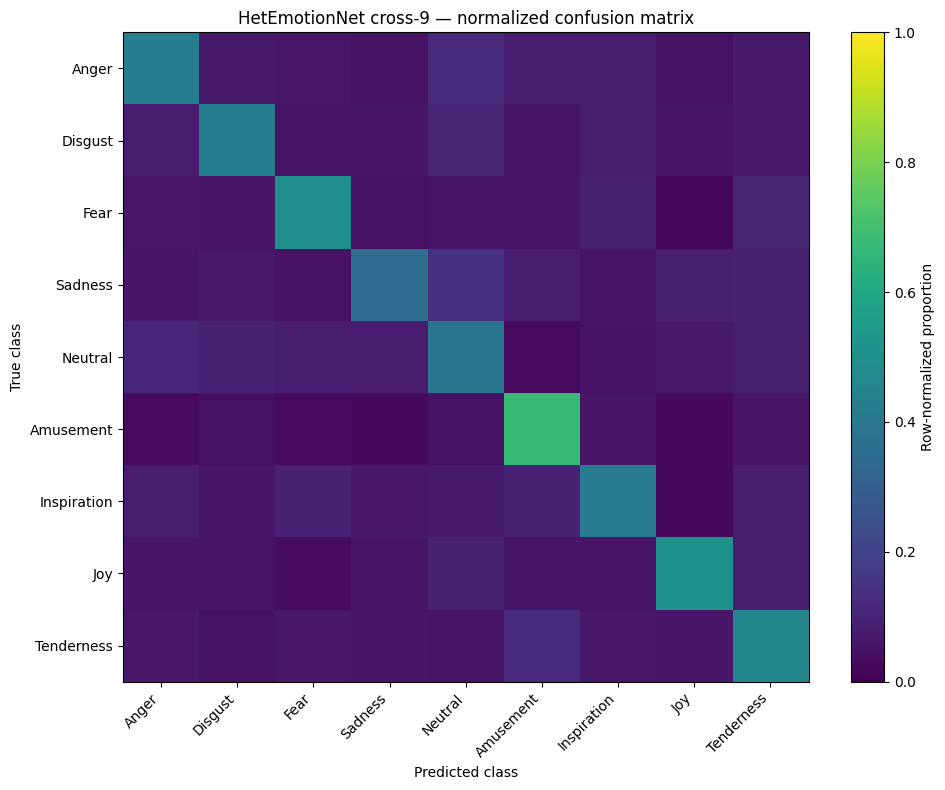

              precision    recall  f1-score   support

       Anger       0.42      0.43      0.43     11070
     Disgust       0.44      0.43      0.44     11070
        Fear       0.50      0.50      0.50     11070
     Sadness       0.44      0.36      0.39     11070
     Neutral       0.43      0.39      0.41     14760
   Amusement       0.53      0.67      0.60     11070
 Inspiration       0.43      0.42      0.43     11070
         Joy       0.55      0.51      0.53     11070
  Tenderness       0.40      0.46      0.42     11070

    accuracy                           0.46    103320
   macro avg       0.46      0.46      0.46    103320
weighted avg       0.46      0.46      0.46    103320



In [32]:
# Cell 57 — Combine predictions and plot the confusion matrix when results exist

if HAS_COMPLETED_RESULTS:
    prediction_files = sorted(RESULT_DIR.glob('outer_*_predictions.csv'))
    if prediction_files:
        all_predictions = pd.concat([pd.read_csv(path) for path in prediction_files], ignore_index=True)
        all_predictions.to_csv(RESULT_DIR / 'all_completed_predictions.csv', index=False)

        matrix = confusion_matrix(
            all_predictions['true_label'],
            all_predictions['predicted_label'],
            labels=np.arange(NUM_CLASSES),
        )
        normalized_matrix = matrix / np.maximum(matrix.sum(axis=1, keepdims=True), 1)

        plt.figure(figsize=(10, 8))
        plt.imshow(normalized_matrix, vmin=0, vmax=1, aspect='auto')
        plt.title(
            f"HetEmotionNet {'intra-9' if CFG.protocol == 'intra_subject' else 'cross-9'} "
            '— normalized confusion matrix'
        )
        plt.xticks(np.arange(NUM_CLASSES), EMOTION_NAMES, rotation=45, ha='right')
        plt.yticks(np.arange(NUM_CLASSES), EMOTION_NAMES)
        plt.xlabel('Predicted class')
        plt.ylabel('True class')
        plt.colorbar(label='Row-normalized proportion')
        plt.tight_layout()
        confusion_path = FIGURE_DIR / 'normalized_confusion_matrix.png'
        plt.savefig(confusion_path, dpi=200, bbox_inches='tight')
        plt.show()

        print(classification_report(
            all_predictions['true_label'],
            all_predictions['predicted_label'],
            labels=np.arange(NUM_CLASSES),
            target_names=EMOTION_NAMES,
            zero_division=0,
        ))
    else:
        all_predictions = pd.DataFrame()
        print('Metrics exist, but no prediction CSV files were found.')
else:
    all_predictions = pd.DataFrame()
    print('Confusion matrix skipped because no final outer-fold predictions exist yet.')


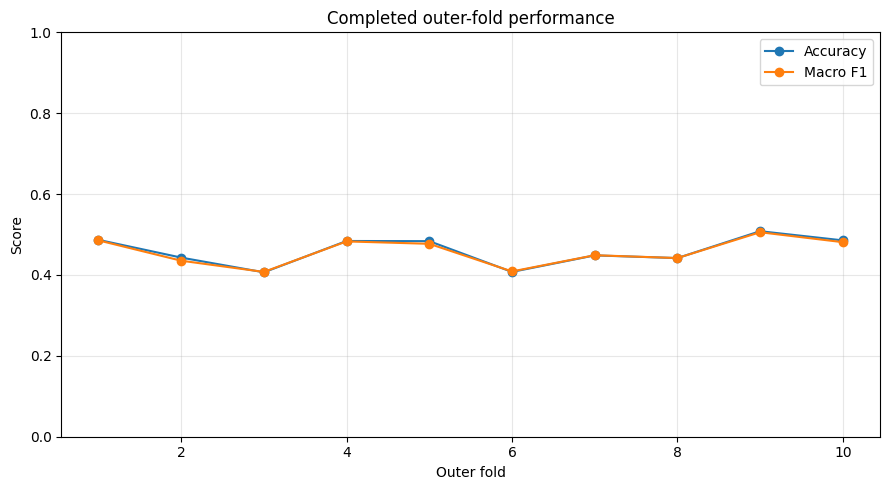

In [33]:
# Cell 58 — Plot completed fold-wise performance when available

if HAS_COMPLETED_RESULTS:
    plt.figure(figsize=(9, 5))
    plt.plot(completed_df['outer_fold'], completed_df['accuracy'], marker='o', label='Accuracy')
    plt.plot(completed_df['outer_fold'], completed_df['macro_f1'], marker='o', label='Macro F1')
    plt.xlabel('Outer fold')
    plt.ylabel('Score')
    plt.ylim(0, 1)
    plt.title('Completed outer-fold performance')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    performance_path = FIGURE_DIR / 'fold_performance.png'
    plt.savefig(performance_path, dpi=200, bbox_inches='tight')
    plt.show()
else:
    print('Fold-performance plot skipped because no final outer fold has completed yet.')


In [34]:
# Cell 59 — Run inference on one saved test sample when a final model exists

if HAS_COMPLETED_RESULTS and not all_predictions.empty:
    best_row = completed_df.sort_values(['accuracy', 'macro_f1'], ascending=False).iloc[0]
    best_fold = int(best_row['outer_fold'])
    best_metrics_path = RESULT_DIR / f'outer_{best_fold:02d}_test_metrics.json'
    with open(best_metrics_path) as handle:
        best_metrics = json.load(handle)

    model_path = CHECKPOINT_DIR / f'outer_{best_fold:02d}' / 'final_model' / 'last.pt'
    best_model = HetEmotionNet(int(best_metrics['hidden_dim']), CFG.dropout, CFG.num_classes).to(DEVICE)
    state = safe_torch_load(model_path, map_location='cpu')
    load_model_state_compatible(best_model, state)
    del state
    best_model.eval()

    sample_row = all_predictions[all_predictions['sample_index'].notna()].iloc[0]
    sample_index = int(sample_row['sample_index'])
    clip_index = int(clip_ids[sample_index])
    with torch.no_grad():
        with autocast_context():
            logits = best_model(
                torch.from_numpy(np.asarray(x_frequency[sample_index]).copy()).unsqueeze(0).to(DEVICE),
                torch.from_numpy(np.asarray(x_temporal_by_clip[clip_index]).copy()).unsqueeze(0).to(DEVICE),
                torch.from_numpy(np.asarray(clip_adjacency[clip_index]).copy()).unsqueeze(0).to(DEVICE),
            )
        probability = torch.softmax(logits.float(), dim=1).cpu().numpy()[0]
    prediction = int(probability.argmax())
    print('Sample index:', sample_index)
    print('True emotion:', EMOTION_NAMES[int(sample_labels[sample_index])])
    print('Predicted emotion:', EMOTION_NAMES[prediction])
    display(
        pd.DataFrame({'emotion': EMOTION_NAMES, 'probability': probability})
        .sort_values('probability', ascending=False)
    )
    del best_model, logits
    clear_runtime_cache()
else:
    print('Inference skipped because no completed final-model prediction is available yet.')


Sample index: 0
True emotion: Anger
Predicted emotion: Anger


,emotion,probability
0,Anger,0.944608
7,Joy,0.017920
8,Tenderness,0.010399
6,Inspiration,0.007869
4,Neutral,0.007189
2,Fear,0.005581
3,Sadness,0.004959
5,Amusement,0.001401
1,Disgust,0.000073


In [35]:
# Cell 60 — Inventory and ZIP every checkpoint, then create the complete resume bundle


def checkpoint_run_type(path: Path) -> str:
    if 'final_model' in path.parts:
        return 'final_model'
    if any(part.startswith('inner_') for part in path.parts):
        return 'inner_validation'
    return 'other'


def named_path_part(path: Path, prefix: str) -> Optional[str]:
    return next((part for part in path.parts if part.startswith(prefix)), None)


def hyperparameter_path_part(path: Path) -> Optional[str]:
    return next((part for part in path.parts if re.fullmatch(r'h\d+_lr.+', part)), None)


def build_checkpoint_inventory(work_root: Path) -> pd.DataFrame:
    rows: List[Dict[str, Any]] = []
    for checkpoint_path in sorted(work_root.rglob('last.pt')):
        run_dir = checkpoint_path.parent
        complete_path = run_dir / 'complete.json'
        history_path = run_dir / 'history.csv'
        completed = False
        target_epochs = None
        if complete_path.exists():
            try:
                with open(complete_path) as handle:
                    complete_data = json.load(handle)
                completed = bool(complete_data.get('completed', False))
                target_epochs = complete_data.get('epochs')
            except Exception:
                pass

        record: Dict[str, Any] = {
            'profile': next((part for part in checkpoint_path.parts if part in PROFILE_NAMES), None),
            'outer_fold': named_path_part(checkpoint_path, 'outer_'),
            'run_type': checkpoint_run_type(checkpoint_path),
            'hyperparameter_run': hyperparameter_path_part(checkpoint_path),
            'inner_fold': named_path_part(checkpoint_path, 'inner_'),
            'completed': completed,
            'target_epochs': target_epochs,
            'history_exists': history_path.exists(),
            'size_mb': round(checkpoint_path.stat().st_size / 1024**2, 3),
            'checkpoint_path': str(checkpoint_path),
            'saved_epoch': None,
            'hidden_dim': None,
            'learning_rate': None,
            'saved_device': None,
            'torch_version': None,
            'load_error': None,
        }
        try:
            checkpoint = safe_torch_load(checkpoint_path, map_location='cpu')
            record.update({
                'saved_epoch': checkpoint.get('epoch'),
                'hidden_dim': checkpoint.get('hidden_dim'),
                'learning_rate': checkpoint.get('learning_rate'),
                'saved_device': checkpoint.get('saved_device'),
                'torch_version': checkpoint.get('torch_version'),
            })
            del checkpoint
        except Exception as exc:
            record['load_error'] = f'{type(exc).__name__}: {exc}'
        rows.append(record)
        gc.collect()
    return pd.DataFrame(rows)


def archive_write_file(archive: zipfile.ZipFile, file_path: Path, arcname: str) -> None:
    # Model tensors and NumPy caches are already compressed poorly; storing
    # them directly is much faster and avoids excessive final-cell CPU time.
    if file_path.suffix.lower() in {'.pt', '.pth', '.ckpt', '.npy', '.npz', '.pkl'}:
        compression = zipfile.ZIP_STORED
    else:
        compression = zipfile.ZIP_DEFLATED
    archive.write(file_path, arcname=arcname, compress_type=compression)


def create_zip_atomically(files: Sequence[Path], archive_path: Path, base_parent: Path) -> Path:
    archive_path.parent.mkdir(parents=True, exist_ok=True)
    temporary = archive_path.with_suffix(archive_path.suffix + '.tmp')
    if temporary.exists():
        temporary.unlink()
    if archive_path.exists():
        archive_path.unlink()
    with zipfile.ZipFile(temporary, 'w', allowZip64=True) as archive:
        for file_path in tqdm(sorted(set(files)), desc=f'Creating {archive_path.name}'):
            if not file_path.is_file():
                continue
            arcname = str(file_path.relative_to(base_parent))
            archive_write_file(archive, file_path, arcname)
    os.replace(temporary, archive_path)
    return archive_path


checkpoint_inventory = build_checkpoint_inventory(WORK_ROOT)
inventory_path = WORK_ROOT / 'checkpoint_inventory.csv'
checkpoint_inventory.to_csv(inventory_path, index=False)

print('Checkpoint inventory:')
print(' - total last.pt files:', len(checkpoint_inventory))
if not checkpoint_inventory.empty:
    print(' - completed runs:', int(checkpoint_inventory['completed'].sum()))
    print(' - incomplete/resumable runs:', int((~checkpoint_inventory['completed']).sum()))
    display(checkpoint_inventory)

output_root = KAGGLE_WORKING if KAGGLE_WORKING.exists() else WORK_ROOT.parent

# ZIP 1: every file inside every profile's checkpoints directory, including
# last.pt, history.csv, complete.json, and any future checkpoint file types.
checkpoint_files: List[Path] = []
for checkpoint_root in WORK_ROOT.rglob('checkpoints'):
    if checkpoint_root.is_dir():
        checkpoint_files.extend(path for path in checkpoint_root.rglob('*') if path.is_file())
checkpoint_files.append(inventory_path)
if (WORK_ROOT / 'run_manifest.json').exists():
    checkpoint_files.append(WORK_ROOT / 'run_manifest.json')

checkpoint_zip_path = output_root / f'{TASK_SLUG}_all_checkpoints.zip'
create_zip_atomically(
    checkpoint_files,
    checkpoint_zip_path,
    base_parent=WORK_ROOT.parent,
)

# ZIP 2: complete workspace needed for the most reliable automatic restart.
resume_zip_path = output_root / f'{TASK_SLUG}_resume_bundle.zip'
full_resume_files = [path for path in WORK_ROOT.rglob('*') if path.is_file()]
create_zip_atomically(
    full_resume_files,
    resume_zip_path,
    base_parent=WORK_ROOT.parent,
)

print('\nCheckpoint archive created:')
print(checkpoint_zip_path)
print('Checkpoint archive size (GB):', round(checkpoint_zip_path.stat().st_size / 1024**3, 4))
print('\nComplete automatic-resume archive created:')
print(resume_zip_path)
print('Resume archive size (GB):', round(resume_zip_path.stat().st_size / 1024**3, 4))
print('\nFor the next session, attach the previous notebook output. No path entry is required.')


print('Download links:')
try:
    from IPython.display import FileLink
    display(FileLink(str(checkpoint_zip_path)))
    display(FileLink(str(resume_zip_path)))
except Exception:
    print('Use the Kaggle Files/Output panel to download the two ZIP files above.')


Checkpoint inventory:
 - total last.pt files: 10
 - completed runs: 10
 - incomplete/resumable runs: 0


,profile,outer_fold,run_type,hyperparameter_run,inner_fold,completed,target_epochs,history_exists,size_mb,checkpoint_path,saved_epoch,hidden_dim,learning_rate,saved_device,torch_version,load_error
0,paper_ncv,outer_01,final_model,None,None,True,3,True,1.123,/kaggle/working/hetemotionnet_processed_FACED_...,3,40,0.0100,None,None,None
1,paper_ncv,outer_02,final_model,None,None,True,8,True,0.709,/kaggle/working/hetemotionnet_processed_FACED_...,8,20,0.0100,None,None,None
2,paper_ncv,outer_03,final_model,None,None,True,9,True,1.136,/kaggle/working/hetemotionnet_processed_FACED_...,9,40,0.0100,cuda:0,2.10.0+cu128,None
3,paper_ncv,outer_04,final_model,None,None,True,45,True,1.136,/kaggle/working/hetemotionnet_processed_FACED_...,45,40,0.0100,cuda:0,2.10.0+cu128,None
4,paper_ncv,outer_05,final_model,None,None,True,20,True,1.965,/kaggle/working/hetemotionnet_processed_FACED_...,20,80,0.0100,cuda:0,2.10.0+cu128,None
5,paper_ncv,outer_06,final_model,None,None,True,7,True,1.137,/kaggle/working/hetemotionnet_processed_FACED_...,7,40,0.0100,cuda:0,2.10.0+cu128,None
6,paper_ncv,outer_07,final_model,None,None,True,13,True,1.137,/kaggle/working/hetemotionnet_processed_FACED_...,13,40,0.0100,cuda:0,2.10.0+cu128,None
7,paper_ncv,outer_08,final_model,None,None,True,3,True,1.965,/kaggle/working/hetemotionnet_processed_FACED_...,3,80,0.0100,cuda:0,2.10.0+cu128,None
8,paper_ncv,outer_09,final_model,None,None,True,21,True,1.137,/kaggle/working/hetemotionnet_processed_FACED_...,21,40,0.0001,cuda:0,2.10.0+cu128,None
9,paper_ncv,outer_10,final_model,None,None,True,5,True,1.137,/kaggle/working/hetemotionnet_processed_FACED_...,5,40,0.0100,cuda:0,2.10.0+cu128,None


Creating hetemotionnet_processed_FACED_cross_9_full_resumable_all_checkpoints.zip:   0%|          | 0/572 [00:…

Creating hetemotionnet_processed_FACED_cross_9_full_resumable_resume_bundle.zip:   0%|          | 0/719 [00:00…


Checkpoint archive created:
/kaggle/working/hetemotionnet_processed_FACED_cross_9_full_resumable_all_checkpoints.zip
Checkpoint archive size (GB): 0.0146

Complete automatic-resume archive created:
/kaggle/working/hetemotionnet_processed_FACED_cross_9_full_resumable_resume_bundle.zip
Resume archive size (GB): 0.2479

For the next session, attach the previous notebook output. No path entry is required.
Download links:


/kaggle/working/hetemotionnet_processed_FACED_cross_9_full_resumable_all_checkpoints.zip

/kaggle/working/hetemotionnet_processed_FACED_cross_9_full_resumable_resume_bundle.zip

# Cell 61 — Notebook complete

The workflow now stores atomic epoch checkpoints and can resume them across CUDA, another CUDA GPU, or CPU. A previous Kaggle notebook output is detected automatically whether it exposes normal folders or either generated ZIP archive.

Generated at the end:

```text
hetemotionnet_processed_FACED_cross_9_full_resumable_all_checkpoints.zip
hetemotionnet_processed_FACED_cross_9_full_resumable_resume_bundle.zip
```

The first archive contains every checkpoint directory. The second contains the complete cache, splits, checkpoints, results, figures, and manifest required for the most reliable automatic continuation.
